# Simulació de Propagació d'Incendi Forestal — Sessió 2

## Descripció

Modelitzem la propagació d'un incendi forestal amb un **autòmat cel·lular m:n-CA^k** representable amb SDL, usant capes generades sintèticament en format IDRISI32 i IDRISI31.

### Objectiu
Simular com s'estén un incendi sobre un terreny heterogeni a partir de:
- Dues capes d'entrada estàtiques: **humitat** i **vegetació** (llegides de fitxers)
- Una capa opcional de **vent** (vectorial)
- Una tercera capa dinàmica: **propagació de l'incendi** (tres estats + escalfament)

El notebook s'estructura en **dos grans apartats**:
1. **Generació de fitxers**: crea els fitxers de les 4 capes en format IDRISI32/31 amb els paràmetres desitjats
2. **Simulació**: llegeix els fitxers, construeix les capes, executa l'autòmat cel·lular i mostra els resultats amb gràfiques d'evolució per a cada experiment

---

### Assumpcions extretes de l'enunciat

1. La **vegetació** representa les **hores de combustió** d'una cel·la: mentre crema, pot propagar foc als veïns.
2. La **humitat** representa les **hores de retard** des que un veí crema fins que la cel·la s'encén.
3. La capa de propagació té **tres estats**: pendent de cremar, en procés de cremar-se i cremat. S'afegeix un quart estat intermedi (`MOIST`) per implementar el retard d'humitat de l'enunciat.
4. La propagació és **determinista**: si la condició es compleix, el canvi d'estat és sempre cert.
5. El **veïnatge és de Moore (8 veïns)**: permet propagació en diagonal, més realista que Von Neumann.
6. Els **temporitzadors** (`burn_timer`, `hum_timer`) s'actualitzen incrementalment pas a pas i el canvi d'estat es produeix **únicament quan s'assoleix el llindar** (no cada pas).

### Assumpcions pròpies de disseny

7. **Mapeig codi de terreny → humitat**: 10 codis IDRISI (`LL`, `CT`, ..., `CAT`) es mapegen a valors [0, 2] hores, ordenats per humitat creixent. Modificable a la secció de configuració.
8. **Hores de combustió per polígon de vegetació**: cada zona del fitxer `.vec` rep un valor d'hores. Modificable a la secció de configuració.
9. **Vent**: es modela com un vector constant que ordena la propagació cap a la seva direcció.
10. **Múltiples focus d'ignició**: es poden definir diverses cel·les inicials de foc per simular incendis simultanis o originals múltiples.

---
# APARTAT 1: GENERACIO DE FITXERS DE CAPES

Aquest apartat genera els fitxers que defineixen les capes del model:
- `humidity.doc` + `humidity.img` -> capa d'humitat (IDRISI32 ASCII)
- `vegetation.doc` + `vegetation.img` -> capa de vegetacio (IDRISI32 ASCII)
- `wind.dvc` + `wind.vec` -> capa de vent (IDRISI31 vectorial, opcional)

Cada joc de fitxers es guarda en un subdirectori sota `dades/` (p. ex. `dades/escenari_a/`).
A l'Apartat 2 pots triar quin escenari vols simular.

In [1]:
import os
import numpy as np

# ════════════════════════════════════════════════════════════════
#  GENERACIÓ ORGÀNICA DE CAPES — Soroll de Perlin
#
#  Perlin noise genera paisatges continus i orgànics sense
#  llibreries externes: cada cel·la es veu influïda pels seus
#  veïns, donant regions naturals en comptes de franges.
# ════════════════════════════════════════════════════════════════

def perlin_noise_2d(rows, cols, scale=10.0, octaves=4, persistence=0.5,
                    lacunarity=2.0, seed=0):
    """
    Genera una graella rows×cols de soroll de Perlin [0, 1].

    Paràmetres:
      scale       : escala base (valors grans → regions més grans)
      octaves     : capes de detall (més octaves → més textura fina)
      persistence : quant pesa cada octava addicional (0-1)
      lacunarity  : multiplicador de freqüència per octava
      seed        : llavor aleatòria per reproduïbilitat
    """
    rng = np.random.default_rng(seed)

    # Gradients aleatoris en una graella de control
    def make_gradients(gx, gy):
        angles = rng.uniform(0, 2 * np.pi, (gy, gx))
        return np.stack([np.cos(angles), np.sin(angles)], axis=-1)

    def fade(t):
        return t * t * t * (t * (t * 6 - 15) + 10)

    def lerp(a, b, t):
        return a + t * (b - a)

    def dot_grad(gx, gy, ix, iy, x, y, grads):
        g = grads[iy % grads.shape[0], ix % grads.shape[1]]
        return g[0] * (x - ix) + g[1] * (y - iy)

    result = np.zeros((rows, cols))
    amplitude = 1.0
    frequency = 1.0
    max_val   = 0.0

    for _ in range(octaves):
        freq_scale = scale / frequency
        gx = int(np.ceil(cols / freq_scale)) + 2
        gy = int(np.ceil(rows / freq_scale)) + 2
        grads = make_gradients(gx, gy)

        for r in range(rows):
            for c in range(cols):
                xf = c / freq_scale
                yf = r / freq_scale
                x0, y0 = int(xf), int(yf)
                x1, y1 = x0 + 1, y0 + 1
                sx, sy = fade(xf - x0), fade(yf - y0)

                n00 = dot_grad(x0, y0, x0, y0, xf, yf, grads)
                n10 = dot_grad(x1, y0, x1, y0, xf, yf, grads)
                n01 = dot_grad(x0, y1, x0, y1, xf, yf, grads)
                n11 = dot_grad(x1, y1, x1, y1, xf, yf, grads)

                result[r, c] += amplitude * lerp(
                    lerp(n00, n10, sx),
                    lerp(n01, n11, sx), sy
                )

        max_val   += amplitude
        amplitude *= persistence
        frequency *= lacunarity

    # Normalitza a [0, 1]
    result = (result / max_val + 1) / 2
    return np.clip(result, 0, 1)


def perlin_noise_2d_fast(rows, cols, scale=10.0, octaves=4,
                          persistence=0.5, lacunarity=2.0, seed=0):
    """
    Versió vectoritzada (ràpida) del soroll de Perlin.
    Evita el doble bucle Python → molt més ràpid per a graelles grans.
    """
    rng = np.random.default_rng(seed)

    def fade(t):
        return t * t * t * (t * (t * 6 - 15) + 10)

    def lerp(a, b, t):
        return a + t * (b - a)

    result    = np.zeros((rows, cols))
    amplitude = 1.0
    frequency = 1.0
    max_val   = 0.0

    for _ in range(octaves):
        freq_scale = scale / frequency
        gx = int(np.ceil(cols / freq_scale)) + 2
        gy = int(np.ceil(rows / freq_scale)) + 2
        angles = rng.uniform(0, 2 * np.pi, (gy, gx))
        gx_arr = np.cos(angles)
        gy_arr = np.sin(angles)

        r_idx = np.arange(rows)
        c_idx = np.arange(cols)
        xf = c_idx / freq_scale          # (cols,)
        yf = r_idx / freq_scale          # (rows,)
        x0 = np.floor(xf).astype(int)
        y0 = np.floor(yf).astype(int)
        sx = fade(xf - x0)               # (cols,)
        sy = fade(yf - y0)               # (rows,)

        def dg(ix, iy, xfv, yfv):
            ix_c = ix % gx; iy_c = iy % gy
            return (gx_arr[iy_c[:, None], ix_c[None, :]] * (xfv[None, :] - ix[None, :]) +
                    gy_arr[iy_c[:, None], ix_c[None, :]] * (yfv[:, None] - iy[:, None]))

        x1 = x0 + 1; y1 = y0 + 1
        n00 = dg(x0, y0, xf, yf)
        n10 = dg(x1, y0, xf, yf)
        n01 = dg(x0, y1, xf, yf)
        n11 = dg(x1, y1, xf, yf)

        layer = lerp(lerp(n00, n10, sx[None, :]),
                     lerp(n01, n11, sx[None, :]),
                     sy[:, None])
        result   += amplitude * layer
        max_val  += amplitude
        amplitude *= persistence
        frequency *= lacunarity

    result = (result / max_val + 1) / 2
    return np.clip(result, 0, 1)


# ════════════════════════════════════════════════════════════════
#  CONFIGURACIÓ DELS ESCENARIS
# ════════════════════════════════════════════════════════════════

ESCENARIS = {
    "base": {
        "descripcio": "Bosc mediterrani típic — humitat i vegetació heterogènies",
        "hum_range":  (1.0, 5.0),   # [min, max] hores de retard
        "veg_range":  (5.0, 15.0),  # [min, max] hores de combustió
        "hum_scale":  8.0,          # escala espacial del soroll (> → taques més grans)
        "veg_scale":  12.0,
        "hum_seed":   42,
        "veg_seed":   17,
        "wind_vector": (0, 0),
    },
    "alta_humitat": {
        "descripcio": "Terreny molt humit — propagació lenta",
        "hum_range":  (4.0, 8.0),
        "veg_range":  (8.0, 18.0),
        "hum_scale":  6.0,
        "veg_scale":  10.0,
        "hum_seed":   99,
        "veg_seed":   55,
        "wind_vector": (0, 0),
    },
    "vent_est": {
        "descripcio": "Bosc sec amb vent cap a l'est",
        "hum_range":  (0.5, 3.0),
        "veg_range":  (4.0, 12.0),
        "hum_scale":  10.0,
        "veg_scale":  14.0,
        "hum_seed":   7,
        "veg_seed":   33,
        "wind_vector": (0, 1),
    },
    "vent_sudest": {
        "descripcio": "Bosc sec amb vent cap al sud-est",
        "hum_range":  (0.5, 2.5),
        "veg_range":  (3.0, 10.0),
        "hum_scale":  9.0,
        "veg_scale":  13.0,
        "hum_seed":   11,
        "veg_seed":   88,
        "wind_vector": (1, 1),
    },
}

GRID_ROWS = 50
GRID_COLS = 50

# ════════════════════════════════════════════════════════════════
#  FUNCIONS D'ESCRIPTURA IDRISI32
# ════════════════════════════════════════════════════════════════

def generate_layer(rows, cols, value_min, value_max, scale, seed, octaves=4):
    """
    Genera una graella orgànica rows×cols amb valors en [value_min, value_max]
    usant soroll de Perlin vectoritzat.
    """
    noise = perlin_noise_2d_fast(rows, cols, scale=scale, octaves=octaves, seed=seed)
    return value_min + noise * (value_max - value_min)


def write_idrisi32_layer(path_doc, path_img, grid, title, value_units, value_label):
    """
    Escriu una capa raster en format IDRISI32 ASCII.
    Cada valor de la graella ocupa una línia al .img.
    """
    rows, cols = grid.shape
    min_val = float(grid.min())
    max_val = float(grid.max())

    doc_content = (
        f"file title  : {title}\n"
        f"data type   : real\n"
        f"file type   : ascii\n"
        f"columns     : {cols}\n"
        f"rows        : {rows}\n"
        f"ref. system : Cartesian\n"
        f"ref. units  : meters\n"
        f"unit dist.  : 1.0\n"
        f"min. X      : 0.0\n"
        f"max. X      : {float(cols)}\n"
        f"min. Y      : 0.0\n"
        f"max. Y      : {float(rows)}\n"
        f"pos'n error : unknown\n"
        f"resolution  : 1\n"
        f"min. value  : {min_val:.4f}\n"
        f"max. value  : {max_val:.4f}\n"
        f"value units : {value_units}\n"
        f"value label : {value_label}\n"
    )

    with open(path_doc, "w") as f:
        f.write(doc_content)

    # Escriu els valors fila per fila, cel·la per cel·la, una per línia
    with open(path_img, "w") as f:
        for r in range(rows):
            for c in range(cols):
                f.write(f"{grid[r, c]:.4f}\n")

    print(f"   ✅ {os.path.basename(path_doc)}  {rows}×{cols}  "          f"rang [{min_val:.2f}, {max_val:.2f}] {value_units}")


def write_idrisi31_wind(path_dvc, path_vec, wind_vector):
    """Genera els fitxers IDRISI31 per a la capa de vent (opcional)."""    
    dr, dc = wind_vector
    dvc_content = (
        f"file title  : Wind direction\n"
        f"id type     : integer\n"
        f"file type   : ascii\n"
        f"object type : line\n"
        f"ref. system : plane\n"
        f"ref. units  : deg\n"
        f"unit dist.  : 1\n"
        f"min. X      : 0\n"
        f"max. X      : 100\n"
        f"min. Y      : 0\n"
        f"max. Y      : 100\n"
        f"wind dr     : {dr}\n"
        f"wind dc     : {dc}\n"
    )
    if dr == 0 and dc == 0:
        vec_content = "0 0\n"
    else:
        cx, cy = 50.0, 50.0
        ex, ey = cx + dc * 30.0, cy + dr * 30.0
        vec_content = f"1 2\n{cx} {cy}\n{ex} {ey}\n0 0\n"

    with open(path_dvc, "w") as f:
        f.write(dvc_content)
    with open(path_vec, "w") as f:
        f.write(vec_content)
    print(f"   ✅ {os.path.basename(path_dvc)}  vent={wind_vector}")


print("✅ Funcions de generació definides (soroll de Perlin vectoritzat).")

✅ Funcions de generació definides (soroll de Perlin vectoritzat).



📁 Escenari 'base': Bosc mediterrani típic — humitat i vegetació heterogènies
   ✅ humidity.doc  50×50  rang [2.29, 3.74] hours
   ✅ vegetation.doc  50×50  rang [8.10, 11.97] hours
   ✅ wind.dvc  vent=(0, 0)

📁 Escenari 'alta_humitat': Terreny molt humit — propagació lenta
   ✅ humidity.doc  50×50  rang [5.24, 6.78] hours
   ✅ vegetation.doc  50×50  rang [11.29, 14.82] hours
   ✅ wind.dvc  vent=(0, 0)

📁 Escenari 'vent_est': Bosc sec amb vent cap a l'est
   ✅ humidity.doc  50×50  rang [1.27, 2.26] hours
   ✅ vegetation.doc  50×50  rang [6.42, 9.39] hours
   ✅ wind.dvc  vent=(0, 1)

📁 Escenari 'vent_sudest': Bosc sec amb vent cap al sud-est
   ✅ humidity.doc  50×50  rang [1.13, 1.93] hours
   ✅ vegetation.doc  50×50  rang [4.95, 7.88] hours
   ✅ wind.dvc  vent=(1, 1)

✅ Tots els fitxers generats correctament.
   Ara pots executar l'Apartat 2 per simular qualsevol escenari.


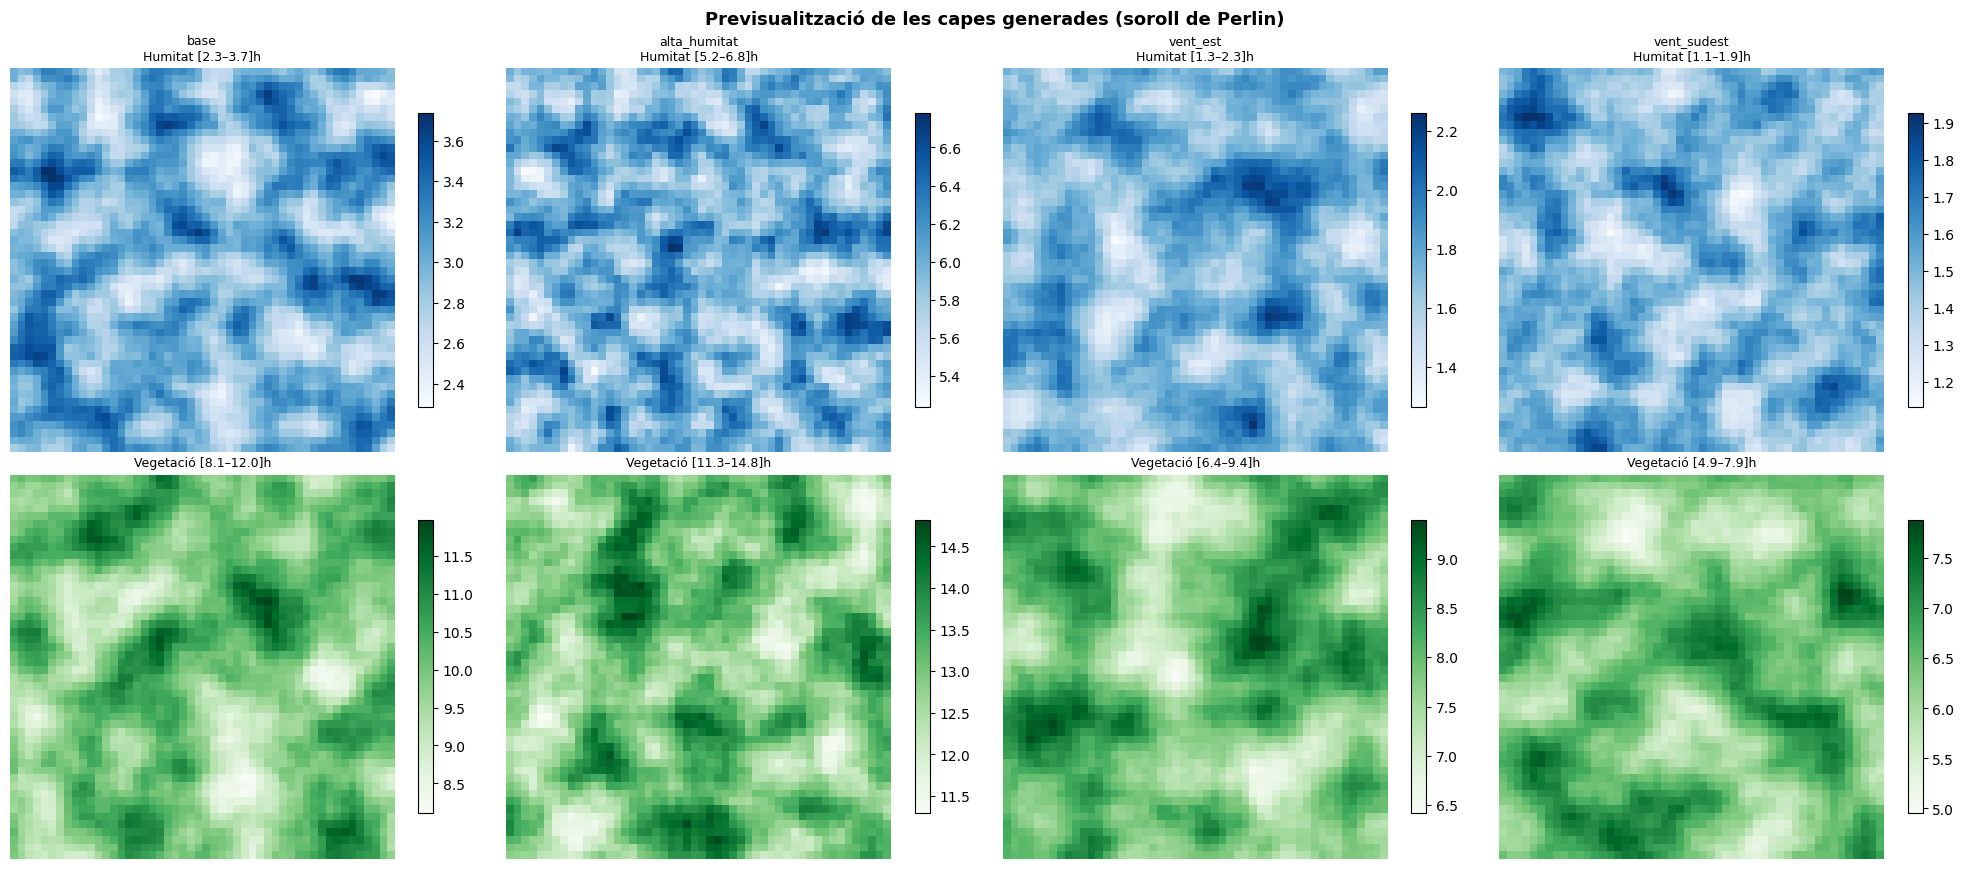

In [2]:
BASE_DIR = "dades"

for nom, cfg in ESCENARIS.items():
    esc_dir = os.path.join(BASE_DIR, nom)
    os.makedirs(esc_dir, exist_ok=True)
    print(f"\n📁 Escenari '{nom}': {cfg['descripcio']}")

    # ── Genera les graelles amb soroll de Perlin ──────────────────
    hum_grid_gen = generate_layer(
        GRID_ROWS, GRID_COLS,
        value_min=cfg["hum_range"][0],
        value_max=cfg["hum_range"][1],
        scale=cfg["hum_scale"],
        seed=cfg["hum_seed"],
    )
    veg_grid_gen = generate_layer(
        GRID_ROWS, GRID_COLS,
        value_min=cfg["veg_range"][0],
        value_max=cfg["veg_range"][1],
        scale=cfg["veg_scale"],
        seed=cfg["veg_seed"],
    )

    # ── Escriu els fitxers IDRISI32 ───────────────────────────────
    write_idrisi32_layer(
        os.path.join(esc_dir, "humidity.doc"),
        os.path.join(esc_dir, "humidity.img"),
        hum_grid_gen,
        title=f"Humidity — {nom}",
        value_units="hours",
        value_label="Humidity delay before ignition",
    )
    write_idrisi32_layer(
        os.path.join(esc_dir, "vegetation.doc"),
        os.path.join(esc_dir, "vegetation.img"),
        veg_grid_gen,
        title=f"Vegetation — {nom}",
        value_units="hours",
        value_label="Burn duration",
    )
    write_idrisi31_wind(
        os.path.join(esc_dir, "wind.dvc"),
        os.path.join(esc_dir, "wind.vec"),
        cfg["wind_vector"],
    )

print("\n✅ Tots els fitxers generats correctament.")
print("   Ara pots executar l'Apartat 2 per simular qualsevol escenari.")

# ── Previsualització de les capes generades ─────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, len(ESCENARIS), figsize=(5 * len(ESCENARIS), 9))
fig.suptitle("Previsualització de les capes generades (soroll de Perlin)",
             fontsize=13, fontweight='bold')

for col, (nom, cfg) in enumerate(ESCENARIS.items()):
    esc_dir = os.path.join(BASE_DIR, nom)

    # Rellegim els fitxers per verificar que s'han escrit bé
    def read_img(path_img, rows, cols):
        vals = []
        with open(path_img) as f:
            for line in f:
                v = line.strip()
                if v: vals.append(float(v))
        grid = np.array(vals).reshape(rows, cols)
        return grid

    hg = read_img(os.path.join(esc_dir, "humidity.img"),   GRID_ROWS, GRID_COLS)
    vg = read_img(os.path.join(esc_dir, "vegetation.img"), GRID_ROWS, GRID_COLS)

    im0 = axes[0, col].imshow(hg, cmap="Blues")
    axes[0, col].set_title(f"{nom}\nHumitat [{hg.min():.1f}–{hg.max():.1f}]h", fontsize=9)
    axes[0, col].axis('off')
    plt.colorbar(im0, ax=axes[0, col], shrink=0.7)

    im1 = axes[1, col].imshow(vg, cmap="Greens")
    axes[1, col].set_title(f"Vegetació [{vg.min():.1f}–{vg.max():.1f}]h", fontsize=9)
    axes[1, col].axis('off')
    plt.colorbar(im1, ax=axes[1, col], shrink=0.7)

plt.tight_layout()
plt.show()

---
# APARTAT 2: SIMULACIÓ DE PROPAGACIÓ D'INCENDI

Aquest apartat llegeix els fitxers generats a l'Apartat 1 i executa la simulació.

**Com usar-lo:**
1. A la cel·la de configuració de simulació, tria l'escenari (`ESCENARI_SELECCIONAT`)
2. Configura els focus d'ignició (`IGNITE_CELLS`) — pots posar-ne més d'un per simular incendis múltiples simultanis
3. Executa la resta de cel·les en ordre

**Cada experiment mostra:**
- Visualització de les capes inicials (humitat + vegetació)
- Gràfic del grid de propagació en els passos clau
- Gràfiques de tendència temporal (cel·les per estat + % territori cremat)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import json

# ─────────────────────────────────────────────────────────
#  ESTATS DE LES CEL·LES
# ─────────────────────────────────────────────────────────
class CellState:
    EMPTY   = 0   # pendent de cremar (vegetació sana)
    MOIST   = 1   # eliminant humitat (retard de l'enunciat)
    BURNING = 2   # cremant → propaga foc als veïns
    BURNED  = 3   # cremat (vegetació consumida)

# ─────────────────────────────────────────────────────────
#  CONFIGURACIÓ DE LA SIMULACIÓ
#
#  Canvia ESCENARI_SELECCIONAT per provar altres escenaris.
#  Canvia IGNITE_CELLS per afegir múltiples focus d'ignició.
# ─────────────────────────────────────────────────────────

ESCENARI_SELECCIONAT = "base"   # opcions: base | alta_humitat | vent_est | vent_sudest

# Focus d'ignició: llista de tuples (fila, columna).
# Un únic focus central:
IGNITE_CELLS = [(25, 25)]

# Exemple amb múltiples focus (descomenta per provar-ho):
# IGNITE_CELLS = [(10, 10), (40, 40), (10, 40)]

# Mida de la graella de simulació
GRID_ROWS = 50
GRID_COLS = 50

# Nombre màxim de passos de simulació
MAX_STEPS = 80

# ─────────────────────────────────────────────────────────
#  COLORS I LLEGENDA
# ─────────────────────────────────────────────────────────
CMAP_COLORS = ["#639922", "#F4C0D1", "#EF9F27", "#444441"]
CMAP = mcolors.ListedColormap(CMAP_COLORS)
NORM = mcolors.BoundaryNorm([0, 1, 2, 3, 4], CMAP.N)
LEGEND_PATCHES = [
    mpatches.Patch(color=CMAP_COLORS[0], label="Vegetació (sana)"),
    mpatches.Patch(color=CMAP_COLORS[1], label="Escalfant-se (humitat)"),
    mpatches.Patch(color=CMAP_COLORS[2], label="En flames"),
    mpatches.Patch(color=CMAP_COLORS[3], label="Cremada"),
]
# Colors RGB per als fotogrames
COLOR_MAP_RGB = {
    CellState.EMPTY:   [60, 160, 60],
    CellState.MOIST:   [244, 192, 209],
    CellState.BURNING: [239, 159, 39],
    CellState.BURNED:  [50, 50, 50],
}

print(f"Escenari seleccionat: '{ESCENARI_SELECCIONAT}'")
print(f"Focus d'ignició     : {IGNITE_CELLS}")
print(f"Graella             : {GRID_ROWS}×{GRID_COLS}")
print(f"Passos màxims       : {MAX_STEPS}")

Escenari seleccionat: 'base'
Focus d'ignició     : [(25, 25)]
Graella             : 50×50
Passos màxims       : 80


## 1. Lectura de fitxers IDRISI32 — Capa d'Humitat

Els fitxers `humidity.doc` (capcalera) i `humidity.img` (dades) segueixen el format IDRISI32 ASCII.
- El `.doc` conte metadades: titol, mides, rang de valors, etc.
- El `.img` conte valors numerics d'humitat (hores de retard).

In [4]:
def parse_idrisi_doc(path):
    """Llegeix una capcalera IDRISI32 (.doc) -> dict clau:valor."""
    meta = {}
    with open(path, "r", errors="ignore") as f:
        for line in f:
            if ":" in line:
                key, _, val = line.partition(":")
                meta[key.strip().lower()] = val.strip()
    return meta


def parse_idrisi_img_ascii(path):
    """Llegeix un fitxer de dades IDRISI32 ASCII -> llista de valors (string)."""
    values = []
    with open(path, "r", errors="ignore") as f:
        for line in f:
            v = line.strip()
            if v:
                values.append(v)
    return values


def build_numeric_grid(values, rows, cols, default_value=0.0):
    """Construeix una graella numerica rows x cols a partir d'una llista de valors."""
    n = len(values)
    grid = np.zeros((rows, cols), dtype=float)
    for r in range(rows):
        for c in range(cols):
            raw = values[(r * cols + c) % n] if n else default_value
            try:
                grid[r, c] = float(raw)
            except ValueError:
                grid[r, c] = float(default_value)
    return grid


# --- Carrega dels fitxers de l'escenari seleccionat ---
esc_dir = os.path.join("dades", ESCENARI_SELECCIONAT)

path_hdoc = os.path.join(esc_dir, "humidity.doc")
path_himg = os.path.join(esc_dir, "humidity.img")

for p in [path_hdoc, path_himg]:
    if not os.path.isfile(p):
        raise FileNotFoundError(
            f"Fitxer no trobat: {p}\n"
            "Executa primer l'Apartat 1 (generacio de fitxers)."
        )

hum_meta  = parse_idrisi_doc(path_hdoc)
hum_vals  = parse_idrisi_img_ascii(path_himg)

ROWS = GRID_ROWS
COLS = GRID_COLS
HUM_MIN = float(hum_meta.get("min. value", 0))
HUM_MAX = float(hum_meta.get("max. value", 2))

hum_grid = build_numeric_grid(
    hum_vals, ROWS, COLS,
    default_value=round((HUM_MIN + HUM_MAX) / 2, 1)
)

print(f"humidity.doc — '{hum_meta.get('file title', '')}'")
print(f"   Graella  : {ROWS} files x {COLS} columnes")
print(f"   Rang     : [{HUM_MIN}, {HUM_MAX}] hores")

humidity.doc — 'Humidity — base'
   Graella  : 50 files x 50 columnes
   Rang     : [2.2861, 3.7359] hores


## 2. Lectura de fitxers IDRISI32 — Capa de Vegetacio

Els fitxers `vegetation.doc` (capcalera) i `vegetation.img` (dades) segueixen el format IDRISI32 ASCII.
La capa conté valors numerics (hores de combustio).

In [5]:
def parse_wind_dvc(path):
    """Llegeix la direccio del vent del fitxer .dvc (opcional)."""
    meta = parse_idrisi_doc(path)
    dr = float(meta.get("wind dr", 0))
    dc = float(meta.get("wind dc", 0))
    return (int(dr), int(dc))


# --- Carrega de vegetacio i vent ---
path_vdoc = os.path.join(esc_dir, "vegetation.doc")
path_vimg = os.path.join(esc_dir, "vegetation.img")
path_wdvc = os.path.join(esc_dir, "wind.dvc")

for p in [path_vdoc, path_vimg]:
    if not os.path.isfile(p):
        raise FileNotFoundError(
            f"Fitxer no trobat: {p}\n"
            "Executa primer l'Apartat 1 (generacio de fitxers)."
        )

veg_meta = parse_idrisi_doc(path_vdoc)
veg_vals = parse_idrisi_img_ascii(path_vimg)

VEG_MIN = float(veg_meta.get("min. value", 0))
VEG_MAX = float(veg_meta.get("max. value", 10))

veg_grid = build_numeric_grid(
    veg_vals, ROWS, COLS,
    default_value=round((VEG_MIN + VEG_MAX) / 2, 1)
)

if os.path.isfile(path_wdvc):
    WIND_DIR = parse_wind_dvc(path_wdvc)
else:
    WIND_DIR = (0, 0)

print(f"vegetation.doc — '{veg_meta.get('file title', '')}'")
print(f"   Rang     : [{VEG_MIN}, {VEG_MAX}] hores")
print(f"   Vent: {WIND_DIR}")

vegetation.doc — 'Vegetation — base'
   Rang     : [8.1037, 11.9725] hores
   Vent: (0, 0)


## 3. Construcció de les capes

Construïm les dues capes d'entrada (humitat i vegetació) i mostrem les seves estadístiques.

In [6]:
# (cel·la buida reservada)

In [7]:
print(f"Graella {ROWS}x{COLS} construida")
print(f"   Humitat    min/max: {hum_grid.min():.2f} / {hum_grid.max():.2f} hores")
print(f"   Vegetacio  min/max: {veg_grid.min():.1f} / {veg_grid.max():.1f} hores")
print(f"   Focus d'ignicio   : {IGNITE_CELLS}")
print(f"   Direccio del vent : {WIND_DIR}")

Graella 50x50 construida
   Humitat    min/max: 2.29 / 3.74 hores
   Vegetacio  min/max: 8.1 / 12.0 hores
   Focus d'ignicio   : [(25, 25)]
   Direccio del vent : (0, 0)


## 4. Visualització de les capes inicials

Les estrelles vermelles (*) indiquen els focus d'ignició inicials.

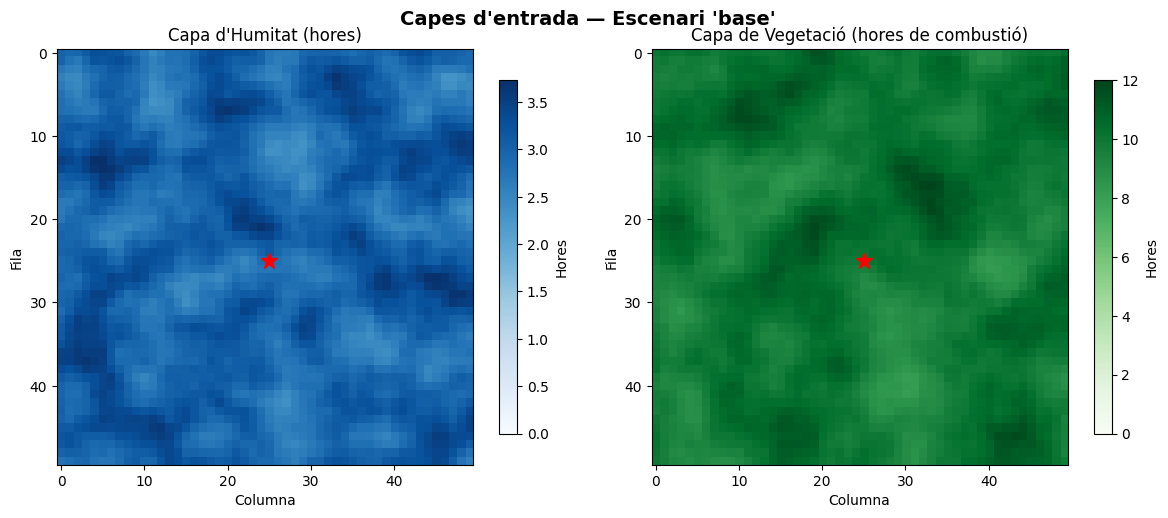

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Capes d'entrada — Escenari '{ESCENARI_SELECCIONAT}'", fontsize=14, fontweight='bold')

im0 = axes[0].imshow(hum_grid, cmap="Blues", vmin=0, vmax=max(2, hum_grid.max()))
axes[0].set_title("Capa d'Humitat (hores)")
axes[0].set_xlabel("Columna"); axes[0].set_ylabel("Fila")
plt.colorbar(im0, ax=axes[0], shrink=0.85, label="Hores")
for (r, c) in IGNITE_CELLS:
    axes[0].plot(c, r, 'r*', markersize=12)

im1 = axes[1].imshow(veg_grid, cmap="Greens", vmin=0, vmax=max(12, veg_grid.max()))
axes[1].set_title("Capa de Vegetació (hores de combustió)")
axes[1].set_xlabel("Columna"); axes[1].set_ylabel("Fila")
plt.colorbar(im1, ax=axes[1], shrink=0.85, label="Hores")
for (r, c) in IGNITE_CELLS:
    axes[1].plot(c, r, 'r*', markersize=12)

plt.tight_layout()
plt.show()

## 5. Model m:n-CA^k — Autòmat Cel·lular

### Regles de transició

| Estat actual | Condició | Estat següent |
|---|---|---|
| `EMPTY` | Veí cremant + humitat > 0 | `MOIST` (comença a escalfar-se) |
| `EMPTY` | Veí cremant + humitat = 0 | `BURNING` (s'encén directament) |
| `MOIST` | `hum_timer` ≥ `humitat_inicial` | `BURNING` (humitat esgotada) |
| `BURNING` | `burn_timer` > `vegetació_inicial` | `BURNED` (vegetació consumida) |

### Efecte del vent

El vent s'implementa com un **bonus de pre-assecament**: quan una cel·la `BURNING` propaga el foc a un veí `EMPTY`, el `hum_timer` del veí s'inicialitza ja avançat en funció de l'alineació entre la direcció del vent i la direcció de propagació.

```
hum_timer_inicial = align(vent, direcció) × WIND_BONUS × hum_init
```

- **`WIND_BONUS = 0.0`** → el vent no té cap efecte (equivalent al model sense vent)
- **`WIND_BONUS = 0.6`** → el vent elimina fins al 60% de la humitat a favor seu
- **`WIND_BONUS = 1.0`** → les cel·les perfectament alineades amb el vent s'encenen sense retard

El model continua sent **completament determinista**: donat un estat inicial i un valor de `WIND_BONUS`, l'evolució és sempre la mateixa.

In [9]:
class WildfireCA:
    """
    Model m:n-CA^k per a la propagació d'un incendi forestal.

    Capes internes:
      state       : CellState de cada cel·la (EMPTY, MOIST, BURNING, BURNED)
      hum_init    : humitat inicial (hores) — capa estàtica d'entrada
      veg_init    : vegetació inicial (hores de combustió) — capa estàtica d'entrada
      burn_timer  : comptador de passos que la cel·la porta cremant
      hum_timer   : comptador de passos que la cel·la porta escalfant-se

    Efecte del vent (WIND_BONUS):
      Quan el vent bufa cap a un veí, el seu hum_timer s'inicialitza amb un bonus
      proporcional a l'alineació amb el vent. Físicament: el vent pre-asseca la cel·la
      receptora, reduint el temps que triga a encendre's. El model segueix sent
      completament determinista.

      WIND_BONUS = fracció de la humitat que el vent elimina d'un cop [0.0 – 1.0]:
        0.0 → el vent no té cap efecte
        0.5 → el vent elimina fins al 50% de la humitat en la seva direcció
        1.0 → les cel·les a favor del vent s'encenen immediatament (sense retard)
    """

    WIND_BONUS = 0.6   # ← ajusta aquí l'intensitat del vent (0.0 – 1.0)

    def __init__(self, humidity_grid, vegetation_grid, wind_dir=(0, 0)):
        self.rows, self.cols = humidity_grid.shape
        self.hum_init  = humidity_grid.copy().astype(float)
        self.veg_init  = vegetation_grid.copy().astype(float)
        self.wind_dir  = wind_dir
        self.max_veg   = max(1.0, float(np.max(vegetation_grid)))
        self.reset()

    def reset(self):
        """Reinicia totes les capes dinàmiques a l'estat inicial."""
        self.state      = np.full((self.rows, self.cols), CellState.EMPTY, dtype=int)
        self.burn_timer = np.zeros((self.rows, self.cols), dtype=float)
        self.hum_timer  = np.zeros((self.rows, self.cols), dtype=float)
        self.veg_cur    = self.veg_init.copy()
        self.step       = 0
        self.history    = []

    def ignite(self, row, col):
        """Encén manualment la cel·la (row, col) com a focus d'ignició inicial."""
        if 0 <= row < self.rows and 0 <= col < self.cols:
            self.state[row, col]      = CellState.BURNING
            self.burn_timer[row, col] = 0
            print(f"   Focus [{row:3d},{col:3d}]  veg={self.veg_init[row,col]:.0f}h  "
                  f"hum={self.hum_init[row,col]:.1f}h")

    def _wind_hum_bonus(self, dr, dc):
        """
        Calcula el bonus de hum_timer per al veí en direcció (dr, dc).

        Si el vent bufa cap a aquest veí (alineació positiva), retorna un
        valor positiu: el hum_timer s'inicialitza ja avançat, reduint el
        retard d'humitat. Com més alineació amb el vent, més bonus.

        Retorna: float en [0, hum_init * WIND_BONUS]
        """
        wr, wc = self.wind_dir
        if wr == 0 and wc == 0:
            return 0.0
        # Producte escalar normalitzat: 1.0 = perfectament alineat, -1.0 = contrari
        dot  = dr * wr + dc * wc
        norm = (wr**2 + wc**2) ** 0.5 * (dr**2 + dc**2) ** 0.5
        align = dot / norm if norm > 0 else 0.0
        # Només apliquem bonus si el vent bufa en aquesta direcció (align > 0)
        return max(0.0, align) * self.WIND_BONUS

    def advance(self):
        """
        Executa un pas de l'autòmat cel·lular (determinista amb efecte de vent).

        Efecte del vent: quan una cel·la BURNING propaga a un veí EMPTY,
        el hum_timer del veí s'inicialitza amb un bonus proporcional a
        l'alineació vent-direcció. Això redueix el temps fins a BURNING.
        """
        new_state      = self.state.copy()
        new_burn_timer = self.burn_timer.copy()
        new_hum_timer  = self.hum_timer.copy()
        new_veg_cur    = self.veg_cur.copy()

        for r in range(self.rows):
            for c in range(self.cols):
                s = self.state[r, c]

                if s == CellState.BURNING:
                    new_burn_timer[r, c] += 1
                    new_veg_cur[r, c] = max(0.0,
                        self.veg_init[r, c] - new_burn_timer[r, c])

                    if new_burn_timer[r, c] > self.veg_init[r, c]:
                        new_state[r, c] = CellState.BURNED
                    else:
                        for dr in [-1, 0, 1]:
                            for dc in [-1, 0, 1]:
                                if dr == 0 and dc == 0:
                                    continue
                                nr, nc = r + dr, c + dc
                                if not (0 <= nr < self.rows and 0 <= nc < self.cols):
                                    continue
                                if self.state[nr, nc] != CellState.EMPTY:
                                    continue

                                # Bonus de vent: pre-asseca el veí en la direcció del vent
                                bonus = self._wind_hum_bonus(dr, dc)
                                hum_efectiva = self.hum_init[nr, nc]

                                if hum_efectiva <= 0:
                                    new_state[nr, nc]      = CellState.BURNING
                                    new_burn_timer[nr, nc] = 0
                                else:
                                    new_state[nr, nc] = CellState.MOIST
                                    # El hum_timer comença avançat pel bonus del vent
                                    new_hum_timer[nr, nc] = bonus * hum_efectiva

                elif s == CellState.MOIST:
                    new_hum_timer[r, c] += 1
                    if new_hum_timer[r, c] >= self.hum_init[r, c]:
                        new_state[r, c]      = CellState.BURNING
                        new_burn_timer[r, c] = 0

        self.state      = new_state
        self.burn_timer = new_burn_timer
        self.hum_timer  = new_hum_timer
        self.veg_cur    = new_veg_cur
        self.step      += 1
        self.history.append(self.state.copy())

    def render_rgb(self):
        """Retorna una imatge RGB amb gradient de color continu per estat i intensitat."""
        img = np.zeros((self.rows, self.cols, 3), dtype=np.uint8)
        for r in range(self.rows):
            for c in range(self.cols):
                s = self.state[r, c]
                if s == CellState.EMPTY:
                    ratio = min(1.0, self.veg_cur[r, c] / self.max_veg)
                    img[r, c] = [0, int(80 + ratio * 150), 0]
                elif s == CellState.MOIST:
                    img[r, c] = [244, 192, 209]
                elif s == CellState.BURNING:
                    ratio = 1.0 - min(1.0, self.veg_cur[r, c] / max(1, self.veg_init[r, c]))
                    img[r, c] = [255, int(200 * (1 - ratio)), 0]
                else:
                    img[r, c] = [50, 50, 50]
        return img

    def frame_rgb(self, state_grid):
        """Genera una imatge RGB a partir d'una capa d'estat (per als fotogrames)."""
        img = np.zeros((self.rows, self.cols, 3), dtype=np.uint8)
        for state, color in COLOR_MAP_RGB.items():
            img[state_grid == state] = color
        return img

    def stats(self):
        total   = self.rows * self.cols
        burning = int(np.sum(self.state == CellState.BURNING))
        moist   = int(np.sum(self.state == CellState.MOIST))
        burned  = int(np.sum(self.state == CellState.BURNED))
        safe    = total - burning - moist - burned
        return {"step": self.step, "burning": burning, "moist": moist,
                "burned": burned, "safe": safe, "total": total}

    def is_active(self):
        return (np.any(self.state == CellState.BURNING) or
                np.any(self.state == CellState.MOIST))


print(f"Classe WildfireCA definida (vent amb bonus d'humitat, WIND_BONUS={WildfireCA.WIND_BONUS}).")

Classe WildfireCA definida (vent amb bonus d'humitat, WIND_BONUS=0.6).


## 6. Execució de la simulació principal

Executa el model CA fins que s'extingeixi el foc o s'arribi al màxim de passos.

In [10]:
ca = WildfireCA(hum_grid, veg_grid, wind_dir=WIND_DIR)

print(f"Encenent {len(IGNITE_CELLS)} focus d'ignició:")
for (r, c) in IGNITE_CELLS:
    ca.ignite(r, c)

stats_history = []

print(f"\n{'Pas':>5}  {'Flames':>9}  {'Escalfant':>11}  {'Cremat':>9}  {'Sa':>7}  {'%Cremat':>8}")
print("-" * 62)

for _ in range(MAX_STEPS):
    if not ca.is_active():
        print("  → Foc extingit.")
        break
    ca.advance()
    s = ca.stats()
    stats_history.append(s)
    pct = s["burned"] / s["total"] * 100
    print(f"{s['step']:>5}  {s['burning']:>9}  {s['moist']:>11}  "
          f"{s['burned']:>9}  {s['safe']:>7}  {pct:>7.1f}%")

print("-" * 62)
sf = ca.stats()
print(f"\nResultat final — Pas {sf['step']}:")
print(f"   Cremat : {sf['burned']:5d} cel·les ({sf['burned']/sf['total']*100:.1f}%)")
print(f"   Sa     : {sf['safe']:5d} cel·les ({sf['safe']/sf['total']*100:.1f}%)")

Encenent 1 focus d'ignició:
   Focus [ 25, 25]  veg=10h  hum=2.9h

  Pas     Flames    Escalfant     Cremat       Sa   %Cremat
--------------------------------------------------------------
    1          1            8          0     2491      0.0%
    2          1            8          0     2491      0.0%
    3          1            8          0     2491      0.0%
    4          8            1          0     2491      0.0%
    5          9           16          0     2475      0.0%
    6          9           16          0     2475      0.0%
    7          9           16          0     2475      0.0%
    8         22            3          0     2475      0.0%
    9         25           21          0     2454      0.0%
   10         25           24          0     2451      0.0%
   11         24           24          1     2451      0.0%
   12         40            8          1     2451      0.0%
   13         45           28          1     2426      0.0%
   14         44           29 

## 7. Gràfiques d'evolució temporal

Mostrem dues gràfiques per a tota la simulació:
- **Esquerra**: nombre de cel·les per estat a cada pas (flames, escalfant-se, cremat, sa)
- **Dreta**: percentatge acumulat del territori cremat

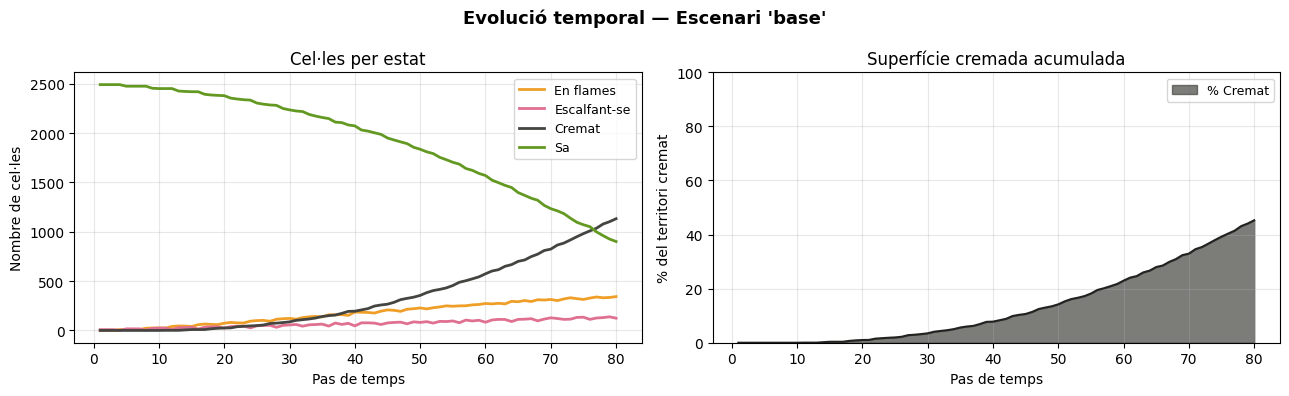

In [11]:
def plot_tendencies(stats_history, ca, title_suffix=""):
    """Dibuixa les gràfiques de tendència temporal de la simulació."""
    if not stats_history:
        print("Cap dada d'evolució disponible.")
        return

    steps   = [s["step"]    for s in stats_history]
    burning = [s["burning"] for s in stats_history]
    moist   = [s["moist"]   for s in stats_history]
    burned  = [s["burned"]  for s in stats_history]
    safe    = [s["safe"]    for s in stats_history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Evolució temporal{' — ' + title_suffix if title_suffix else ''}",
                 fontsize=13, fontweight='bold')

    ax1.plot(steps, burning, color="#EF9F27", lw=2, label="En flames")
    ax1.plot(steps, moist,   color="#E07090", lw=2, label="Escalfant-se")
    ax1.plot(steps, burned,  color="#444441", lw=2, label="Cremat")
    ax1.plot(steps, safe,    color="#639922", lw=2, label="Sa")
    ax1.set_xlabel("Pas de temps"); ax1.set_ylabel("Nombre de cel·les")
    ax1.set_title("Cel·les per estat")
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    pct_burned = [b / ca.rows / ca.cols * 100 for b in burned]
    ax2.fill_between(steps, pct_burned, color="#444441", alpha=0.7, label="% Cremat")
    ax2.plot(steps, pct_burned, color="#222220", lw=1.5)
    ax2.set_xlabel("Pas de temps"); ax2.set_ylabel("% del territori cremat")
    ax2.set_title("Superfície cremada acumulada")
    ax2.set_ylim(0, 100); ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


plot_tendencies(stats_history, ca, title_suffix=f"Escenari '{ESCENARI_SELECCIONAT}'")

## 8. Visualització del resultat final

Mostrem les tres capes juntes: humitat inicial, vegetació inicial i estat final de la propagació.
Les estrelles blanques marquen els focus d'ignició.

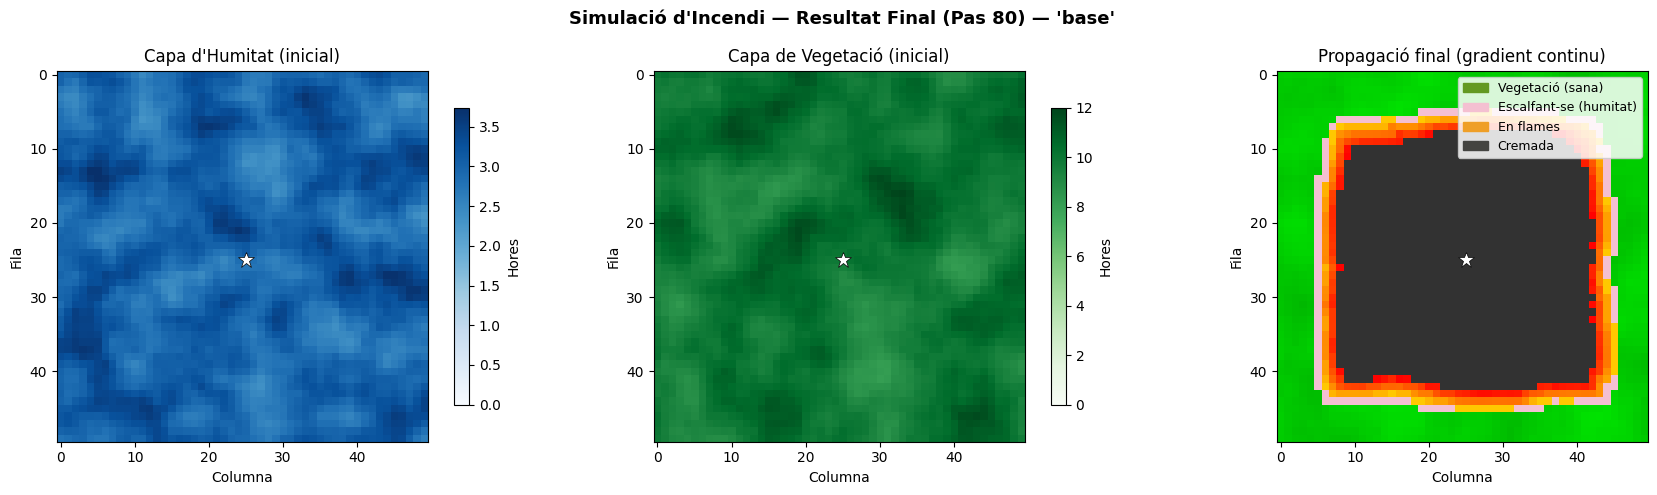

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Simulació d'Incendi — Resultat Final (Pas {ca.step}) — '{ESCENARI_SELECCIONAT}'",
             fontsize=13, fontweight='bold')

im0 = axes[0].imshow(hum_grid, cmap="Blues", vmin=0, vmax=max(2, hum_grid.max()))
axes[0].set_title("Capa d'Humitat (inicial)")
axes[0].set_xlabel("Columna"); axes[0].set_ylabel("Fila")
plt.colorbar(im0, ax=axes[0], shrink=0.8, label="Hores")

im1 = axes[1].imshow(veg_grid, cmap="Greens", vmin=0, vmax=max(12, veg_grid.max()))
axes[1].set_title("Capa de Vegetació (inicial)")
axes[1].set_xlabel("Columna"); axes[1].set_ylabel("Fila")
plt.colorbar(im1, ax=axes[1], shrink=0.8, label="Hores")

axes[2].imshow(ca.render_rgb())
axes[2].set_title("Propagació final (gradient continu)")
axes[2].set_xlabel("Columna"); axes[2].set_ylabel("Fila")
axes[2].legend(handles=LEGEND_PATCHES, loc="upper right", fontsize=9, framealpha=0.85)

for ax in axes:
    for (r, c) in IGNITE_CELLS:
        ax.plot(c, r, 'w*', markersize=12, markeredgecolor='black', markeredgewidth=0.5)

plt.tight_layout()
plt.show()

## 9. Fotogrames de la propagació

Mostrem 12 instantànies de la simulació distribuïdes uniformement en el temps.

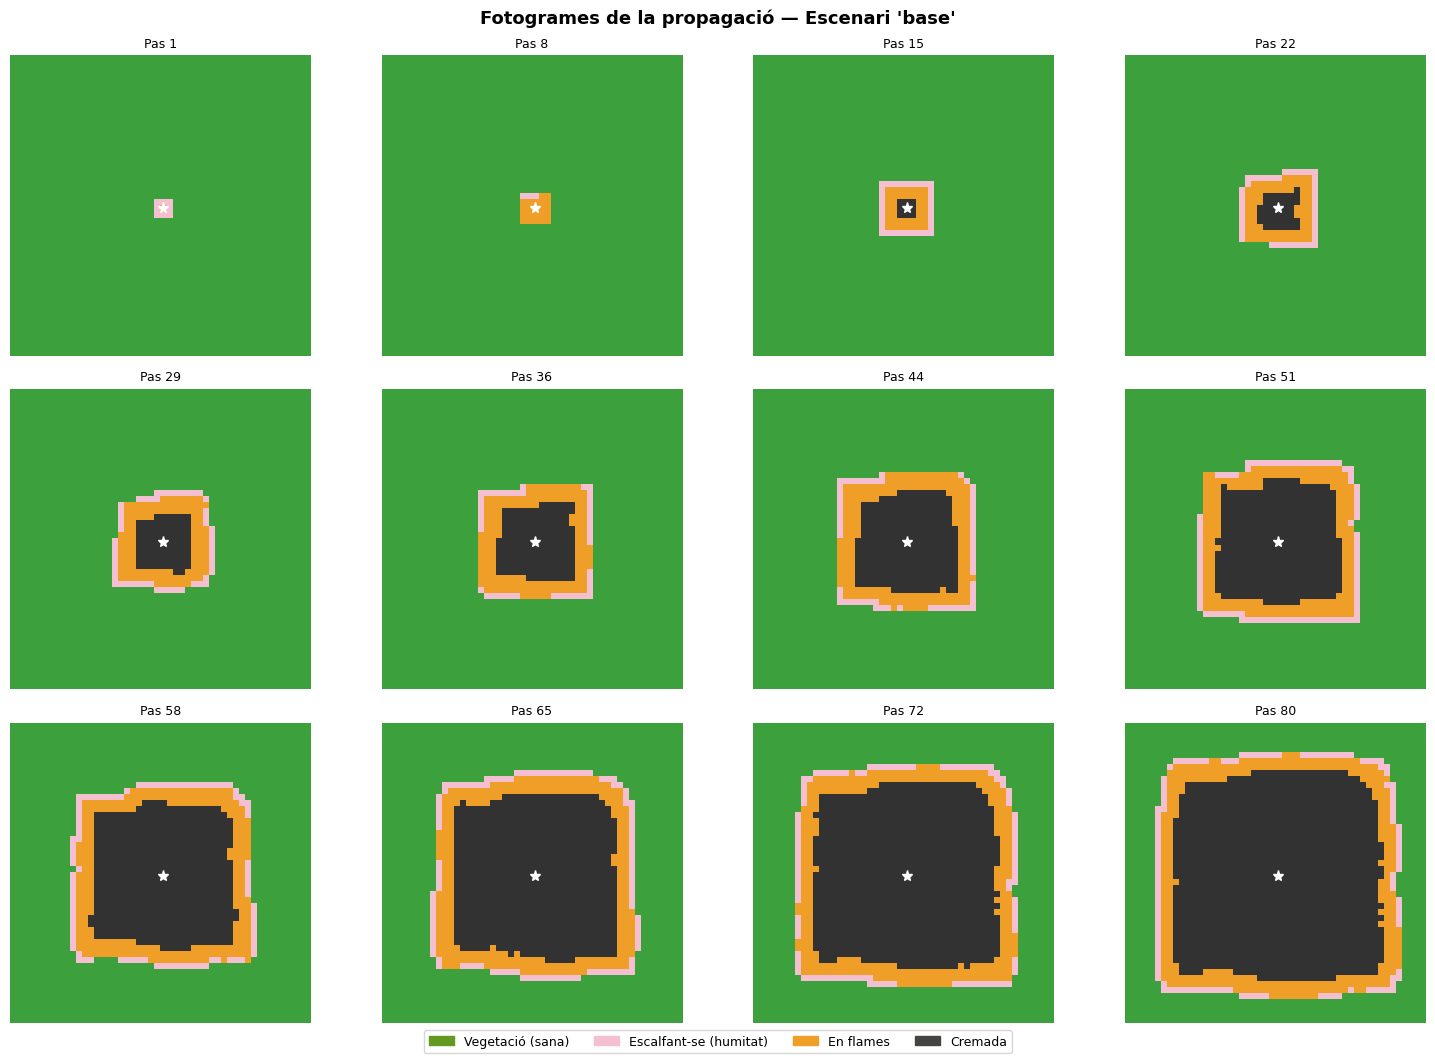

In [13]:
def plot_frames(ca, ignite_cells, title_suffix=""):
    """Dibuixa una graella de fotogrames de la propagació de l'incendi."""
    if not ca.history:
        print("Cap historial disponible.")
        return

    n_frames = len(ca.history)
    indices  = np.linspace(0, n_frames - 1, min(12, n_frames), dtype=int)

    ncols = 4
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.8, nrows * 3.5))
    axes = axes.flatten()
    fig.suptitle(
        f"Fotogrames de la propagació{' — ' + title_suffix if title_suffix else ''}",
        fontsize=13, fontweight='bold'
    )

    for i, idx in enumerate(indices):
        frame = ca.history[idx]
        img = np.zeros((ca.rows, ca.cols, 3), dtype=np.uint8)
        for state, color in COLOR_MAP_RGB.items():
            img[frame == state] = color
        axes[i].imshow(img)
        axes[i].set_title(f"Pas {idx + 1}", fontsize=9)
        axes[i].axis('off')
        for (r, c) in ignite_cells:
            axes[i].plot(c, r, 'w*', markersize=8)

    for j in range(len(indices), len(axes)):
        axes[j].axis('off')

    fig.legend(handles=LEGEND_PATCHES, loc='lower center',
               ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()


plot_frames(ca, IGNITE_CELLS, title_suffix=f"Escenari '{ESCENARI_SELECCIONAT}'",)

---
# EXPERIMENTS

A continuació es presenten tres experiments independents, cadascun amb les seves gràfiques d'evolució temporal i fotogrames de propagació.

**Tots els experiments comparteixen la mateixa funció auxiliar `run_experiment`**, que:
1. Inicialitza el model CA amb les capes i paràmetres indicats
2. Executa la simulació fins a l'extinció o el màxim de passos
3. Mostra el grid final + gràfiques de tendència + fotogrames

In [14]:
def run_experiment(label, hum_grid, veg_grid, ignite_cells, wind_dir=(0, 0),
                   max_steps=80):
    """
    Executa un experiment complet de simulació d'incendi i mostra tots els gràfics.

    Paràmetres:
      label        : nom descriptiu de l'experiment (per als títols)
      hum_grid     : graella d'humitat (numpy array)
      veg_grid     : graella de vegetació (numpy array)
      ignite_cells : llista de tuples (fila, columna) dels focus d'ignició
      wind_dir     : tuple (dr, dc) — direcció del vent
      max_steps    : nombre màxim de passos

    Retorna el model WildfireCA amb l'historial complet.
    """
    nom_vent = {(0,0): "sense vent", (0,1): "est", (0,-1): "oest",
                (1,0): "sud", (-1,0): "nord", (1,1): "sud-est",
                (-1,-1): "nord-oest", (1,-1): "sud-oest", (-1,1): "nord-est"}
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {label}")
    print(f"  Focus d'ignició : {ignite_cells}")
    print(f"  Vent            : {wind_dir} ({nom_vent.get(wind_dir, str(wind_dir))})")
    print(f"{'='*60}")

    ca_exp = WildfireCA(hum_grid, veg_grid, wind_dir=wind_dir)

    for (r, c) in ignite_cells:
        ca_exp.ignite(r, c)

    sh = []
    for _ in range(max_steps):
        if not ca_exp.is_active():
            print("  → Foc extingit.")
            break
        ca_exp.advance()
        sh.append(ca_exp.stats())

    sf = ca_exp.stats()
    print(f"\n  Resultat final — Pas {sf['step']}:")
    print(f"    Cremat : {sf['burned']:5d} cel·les ({sf['burned']/sf['total']*100:.1f}%)")
    print(f"    Sa     : {sf['safe']:5d} cel·les ({sf['safe']/sf['total']*100:.1f}%)")

    # ── Grid final ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{label} — Resultat Final (Pas {ca_exp.step})",
                 fontsize=13, fontweight='bold')
    im0 = axes[0].imshow(hum_grid, cmap="Blues", vmin=0, vmax=max(2, hum_grid.max()))
    axes[0].set_title("Humitat inicial")
    plt.colorbar(im0, ax=axes[0], shrink=0.8, label="Hores")
    im1 = axes[1].imshow(veg_grid, cmap="Greens", vmin=0, vmax=max(12, veg_grid.max()))
    axes[1].set_title("Vegetació inicial")
    plt.colorbar(im1, ax=axes[1], shrink=0.8, label="Hores")
    axes[2].imshow(ca_exp.render_rgb())
    axes[2].set_title("Propagació final")
    axes[2].legend(handles=LEGEND_PATCHES, loc="upper right", fontsize=9, framealpha=0.85)
    for ax in axes:
        ax.set_xlabel("Columna"); ax.set_ylabel("Fila")
        for (r2, c2) in ignite_cells:
            ax.plot(c2, r2, 'w*', markersize=12, markeredgecolor='black', markeredgewidth=0.5)
    plt.tight_layout(); plt.show()

    # ── Gràfiques de tendència ────────────────────────────────────────────────
    plot_tendencies(sh, ca_exp, title_suffix=label)

    # ── Fotogrames ────────────────────────────────────────────────────────────
    plot_frames(ca_exp, ignite_cells, title_suffix=label)

    return ca_exp, sh


print("Funció run_experiment definida.")

Funció run_experiment definida.


## Experiment 1: Múltiples focus d'ignició simultanis

Simulem un incendi amb **tres focus d'ignició simultanis** (un central i dos als extrems).
Esperem que els fronts de foc creixents acabin fusionant-se, accelerant la propagació total.


EXPERIMENT: Exp.1 — Múltiples focus (central + 2 extrems)
  Focus d'ignició : [(25, 25), (5, 5), (44, 44)]
  Vent            : (0, 0) (sense vent)
   Focus [ 25, 25]  veg=10h  hum=2.9h
   Focus [  5,  5]  veg=10h  hum=3.1h
   Focus [ 44, 44]  veg=11h  hum=3.2h

  Resultat final — Pas 80:
    Cremat :  1721 cel·les (68.8%)
    Sa     :   446 cel·les (17.8%)


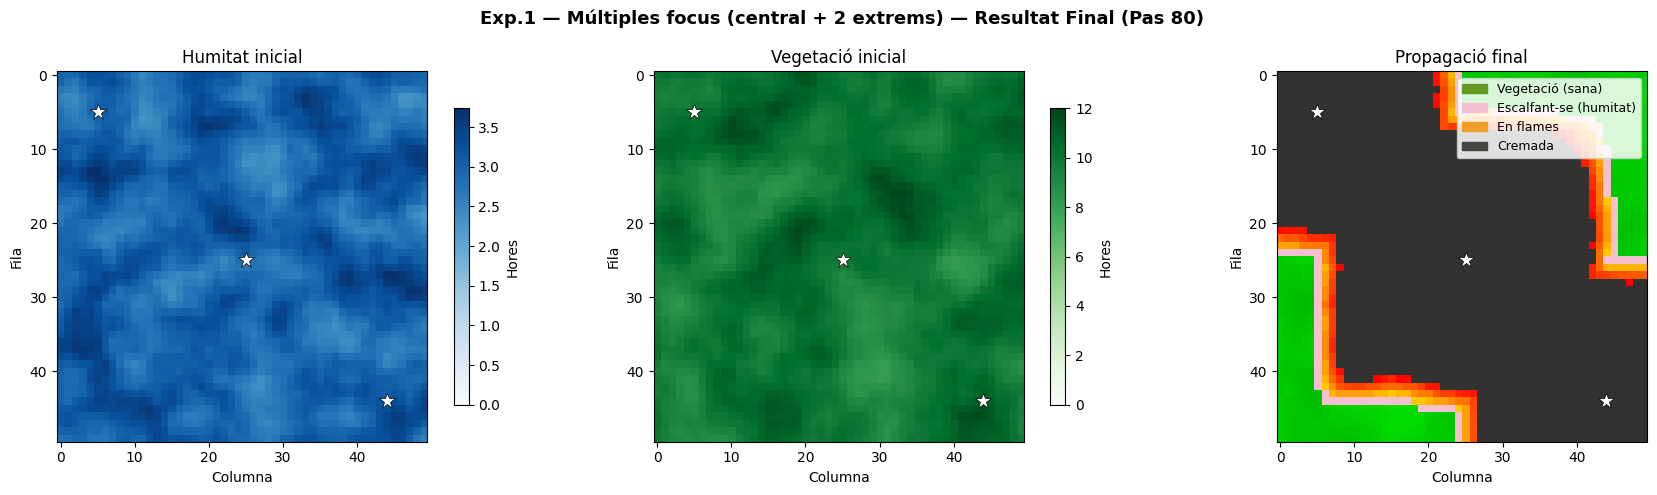

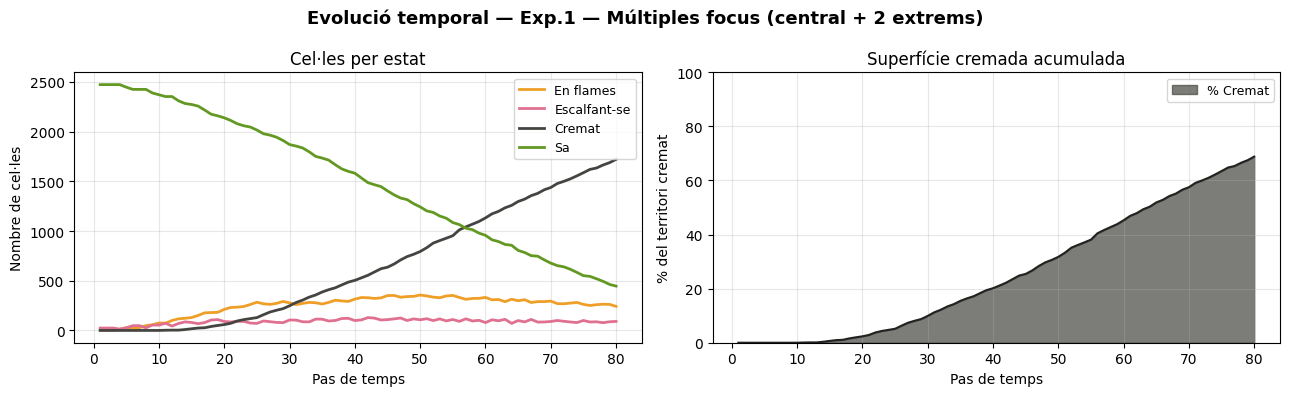

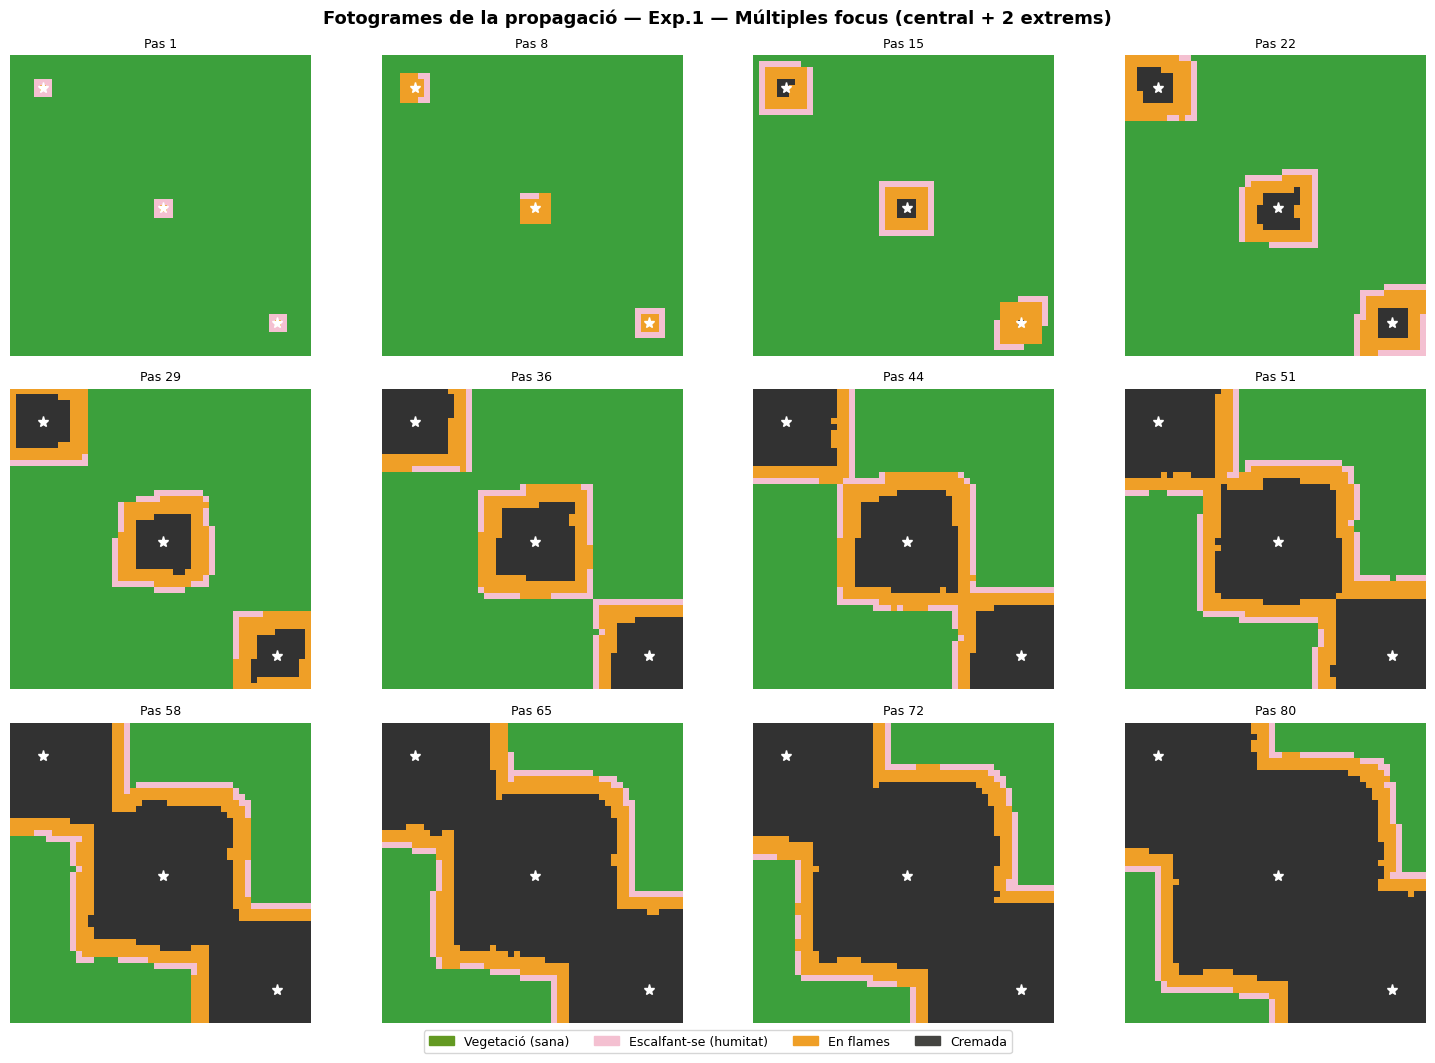

In [15]:
# Experiment 1: tres focus d'ignició simultanis
# Usem el l'escenari 'base' (ja carregat a hum_grid / veg_grid)

ca_exp1, sh1 = run_experiment(
    label="Exp.1 — Múltiples focus (central + 2 extrems)",
    hum_grid=hum_grid,
    veg_grid=veg_grid,
    ignite_cells=[(25, 25), (5, 5), (44, 44)],   # focus central + dos extrems
    wind_dir=(0, 0),
    max_steps=MAX_STEPS,
)

## Experiment 2: Comparació de focus únics vs. múltiples en escenari d'alta humitat

Comparem l'efecte de tenir un únic focus central versus quatre focus als quatre cantons,
en el **escenari d'alta humitat** (propagació molt més lenta).


EXPERIMENT: Exp.2a — Alta humitat, 1 focus central
  Focus d'ignició : [(25, 25)]
  Vent            : (0, 0) (sense vent)
   Focus [ 25, 25]  veg=13h  hum=5.7h

  Resultat final — Pas 80:
    Cremat :   343 cel·les (13.7%)
    Sa     :  1910 cel·les (76.4%)


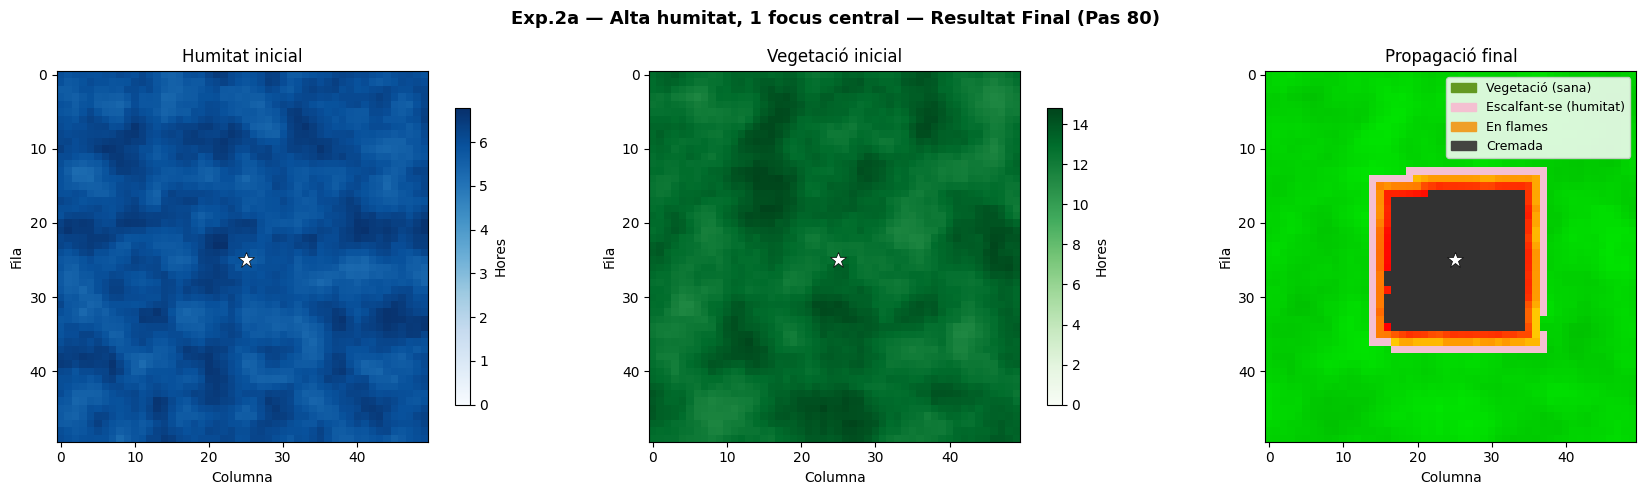

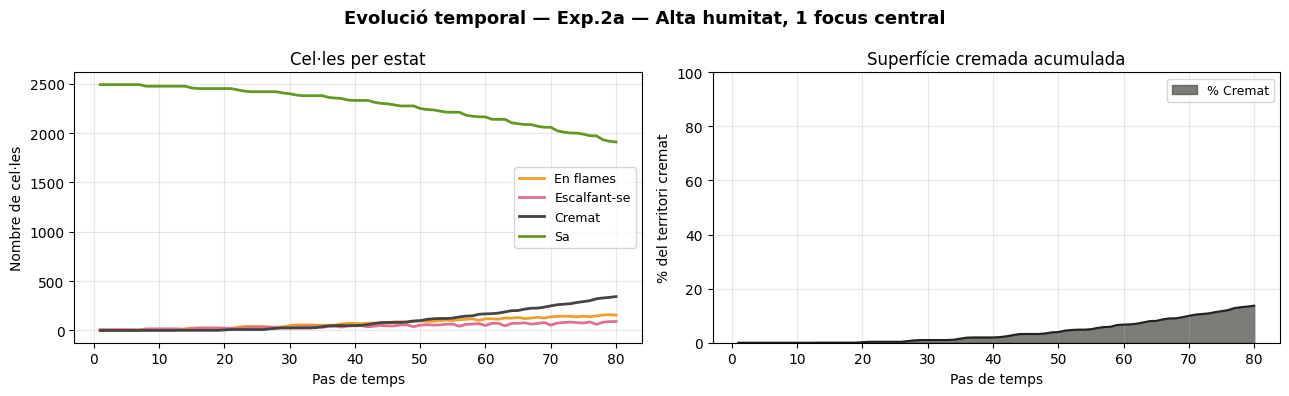

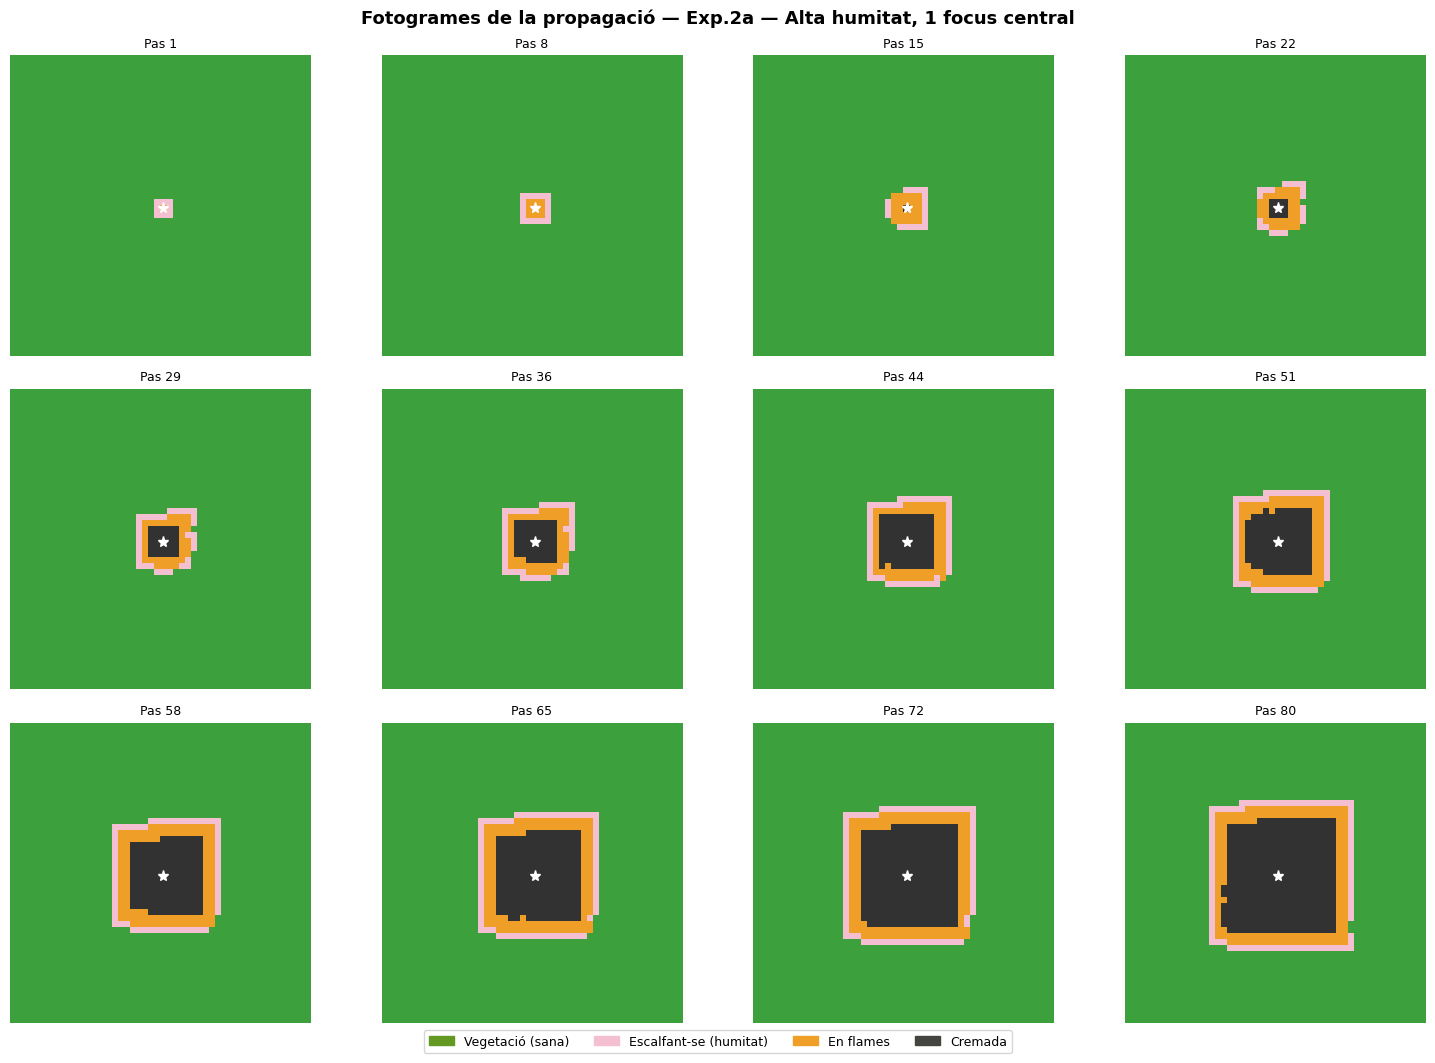


EXPERIMENT: Exp.2b — Alta humitat, 4 focus als cantons
  Focus d'ignició : [(5, 5), (5, 44), (44, 5), (44, 44)]
  Vent            : (0, 0) (sense vent)
   Focus [  5,  5]  veg=12h  hum=5.9h
   Focus [  5, 44]  veg=12h  hum=6.0h
   Focus [ 44,  5]  veg=13h  hum=5.6h
   Focus [ 44, 44]  veg=13h  hum=6.3h

  Resultat final — Pas 80:
    Cremat :   880 cel·les (35.2%)
    Sa     :  1274 cel·les (51.0%)


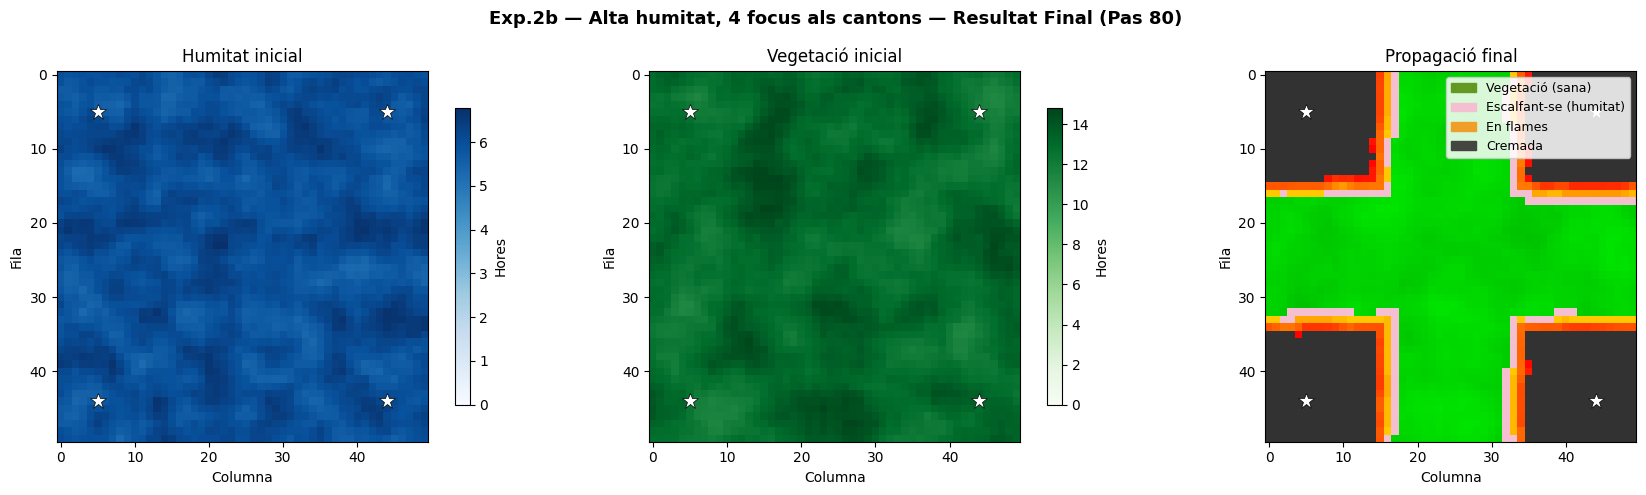

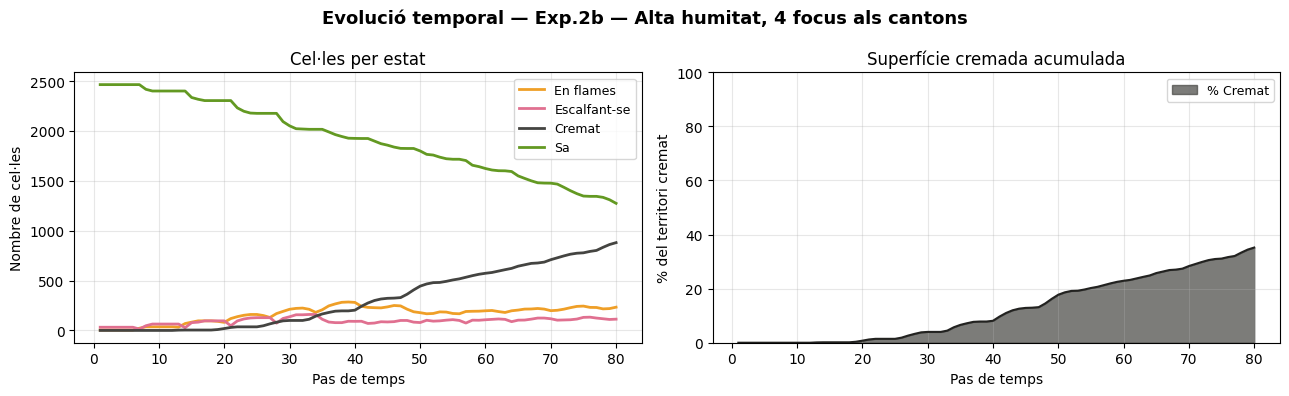

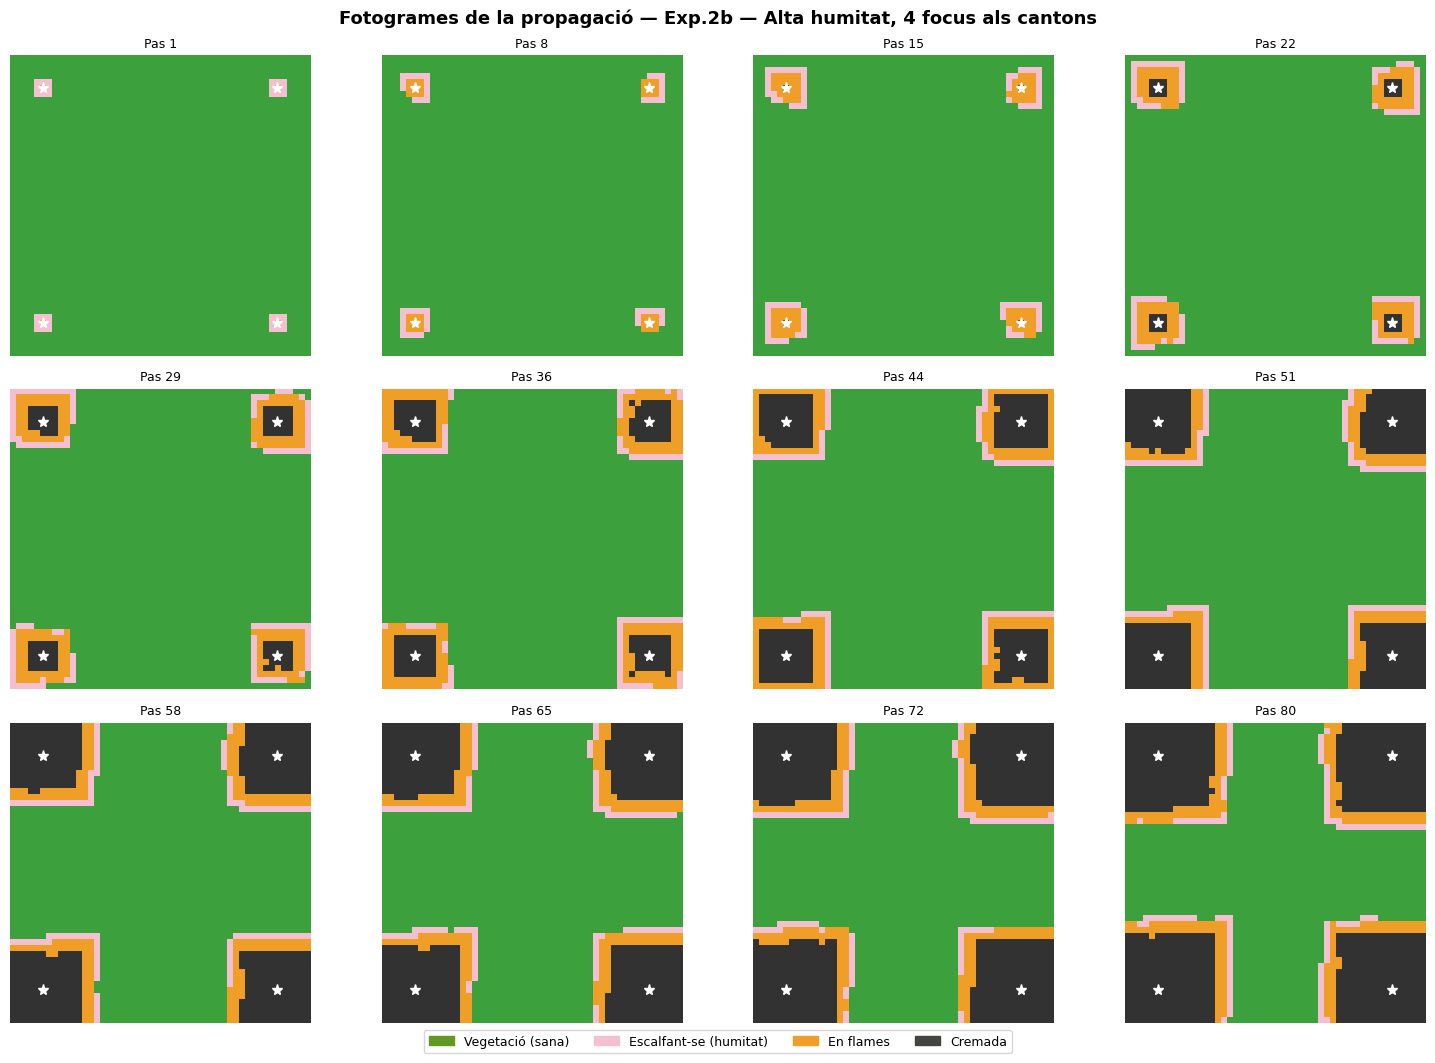

In [16]:
# Carrega les capes de l'escenari 'alta_humitat'
esc_dir_ah  = os.path.join("dades", "alta_humitat")
hum_meta_ah = parse_idrisi_doc(os.path.join(esc_dir_ah, "humidity.doc"))
img_vals_ah = parse_idrisi_img_ascii(os.path.join(esc_dir_ah, "humidity.img"))

hum_ah = build_numeric_grid(
    img_vals_ah, GRID_ROWS, GRID_COLS,
    default_value=float(hum_meta_ah.get("min. value", 1.0))
)

veg_meta_ah = parse_idrisi_doc(os.path.join(esc_dir_ah, "vegetation.doc"))
veg_vals_ah = parse_idrisi_img_ascii(os.path.join(esc_dir_ah, "vegetation.img"))
veg_ah = build_numeric_grid(
    veg_vals_ah, GRID_ROWS, GRID_COLS,
    default_value=float(veg_meta_ah.get("min. value", 3.0))
)

# Sub-experiment A: un focus central
ca_exp2a, sh2a = run_experiment(
    label="Exp.2a — Alta humitat, 1 focus central",
    hum_grid=hum_ah, veg_grid=veg_ah,
    ignite_cells=[(25, 25)],
    wind_dir=(0, 0), max_steps=MAX_STEPS,
)

# Sub-experiment B: quatre focus als cantons
ca_exp2b, sh2b = run_experiment(
    label="Exp.2b — Alta humitat, 4 focus als cantons",
    hum_grid=hum_ah, veg_grid=veg_ah,
    ignite_cells=[(5, 5), (5, 44), (44, 5), (44, 44)],
    wind_dir=(0, 0), max_steps=MAX_STEPS,
)

## Experiment 3: Comparació de les 4 condicions de vent (múltiples focus)

Comparem l'efecte de la **direcció del vent** sobre la propagació usant **dos focus d'ignició** (superior-esquerre i inferior-dret).
Les gràfiques de tendència es mostren per a cada condició de vent.


EXPERIMENT: Exp.3a — Sense vent
  Focus d'ignició : [(8, 8), (41, 41)]
  Vent            : (0, 0) (sense vent)
   Focus [  8,  8]  veg=11h  hum=3.0h
   Focus [ 41, 41]  veg=10h  hum=3.1h

  Resultat final — Pas 80:
    Cremat :  1265 cel·les (50.6%)
    Sa     :   908 cel·les (36.3%)


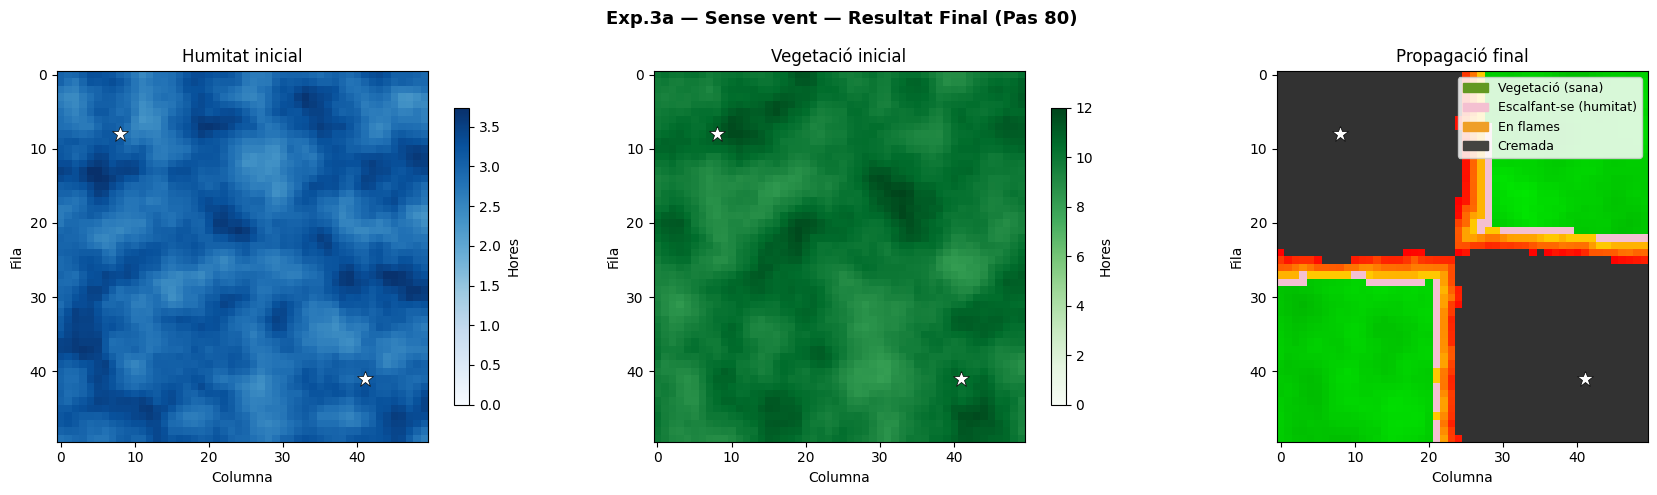

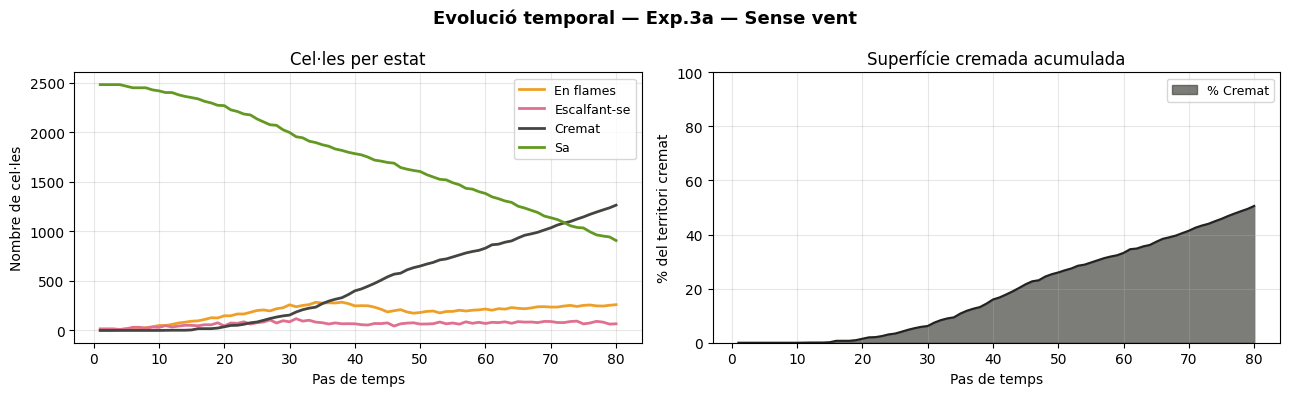

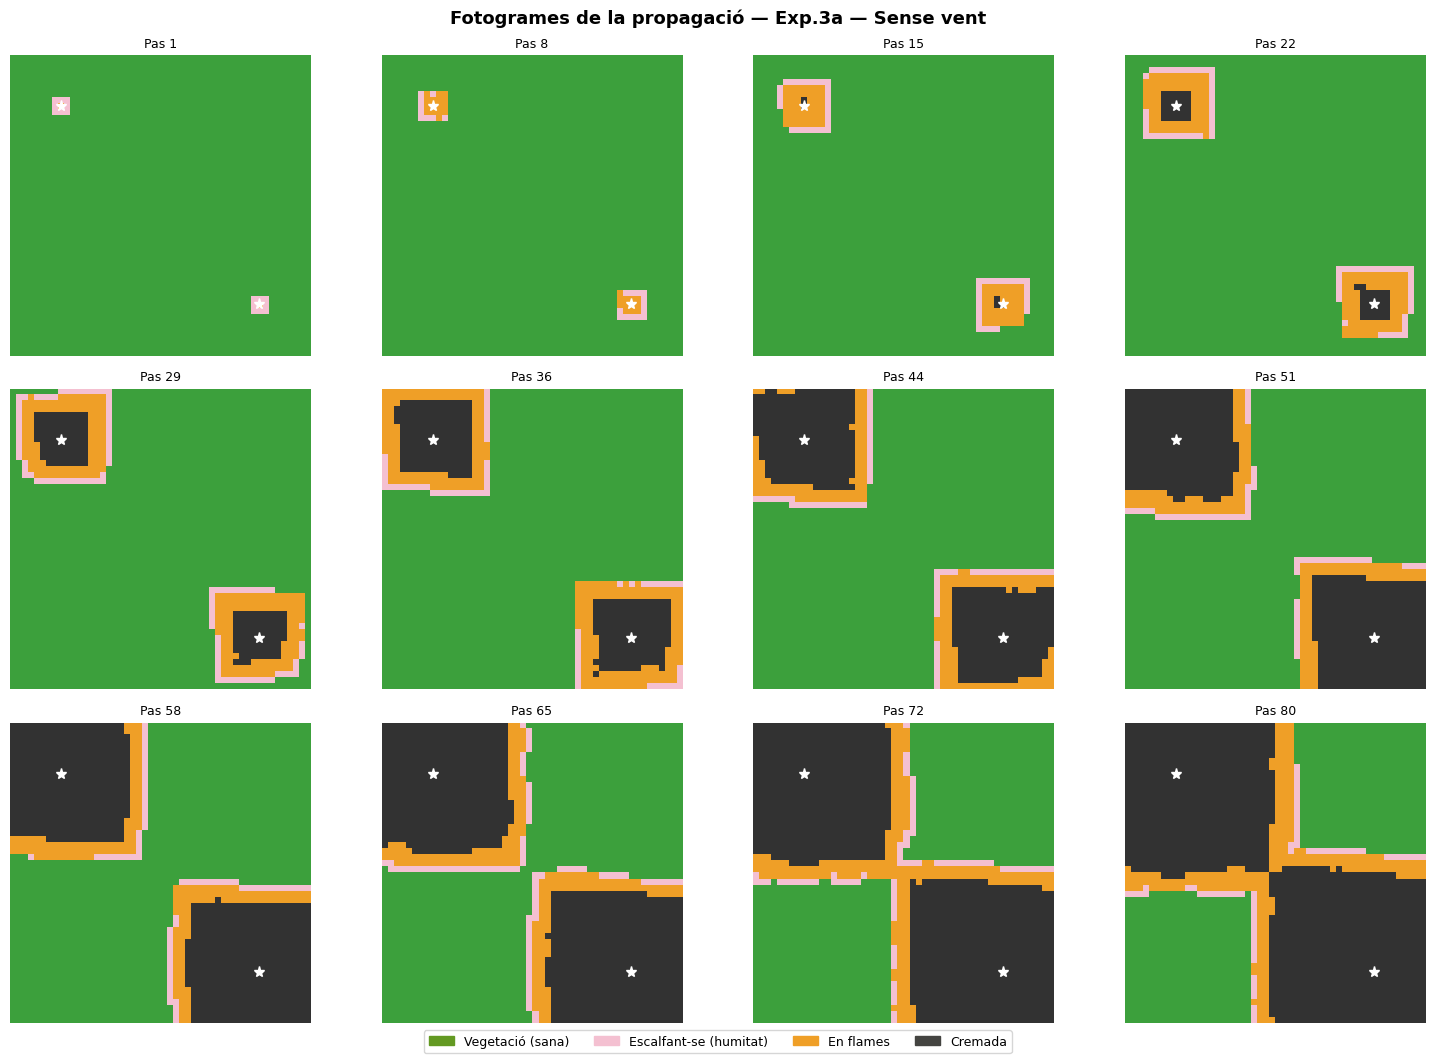


EXPERIMENT: Exp.3b — Vent Est (→)
  Focus d'ignició : [(8, 8), (41, 41)]
  Vent            : (0, 1) (est)
   Focus [  8,  8]  veg=11h  hum=3.0h
   Focus [ 41, 41]  veg=10h  hum=3.1h

  Resultat final — Pas 80:
    Cremat :  1573 cel·les (62.9%)
    Sa     :   626 cel·les (25.0%)


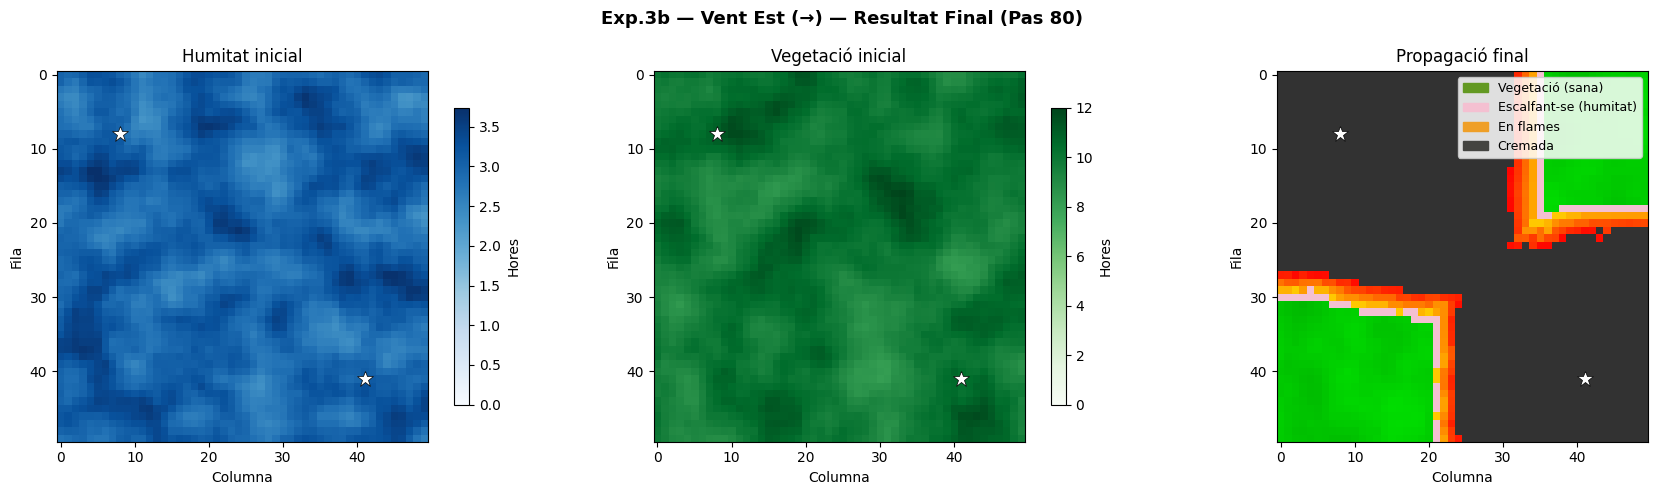

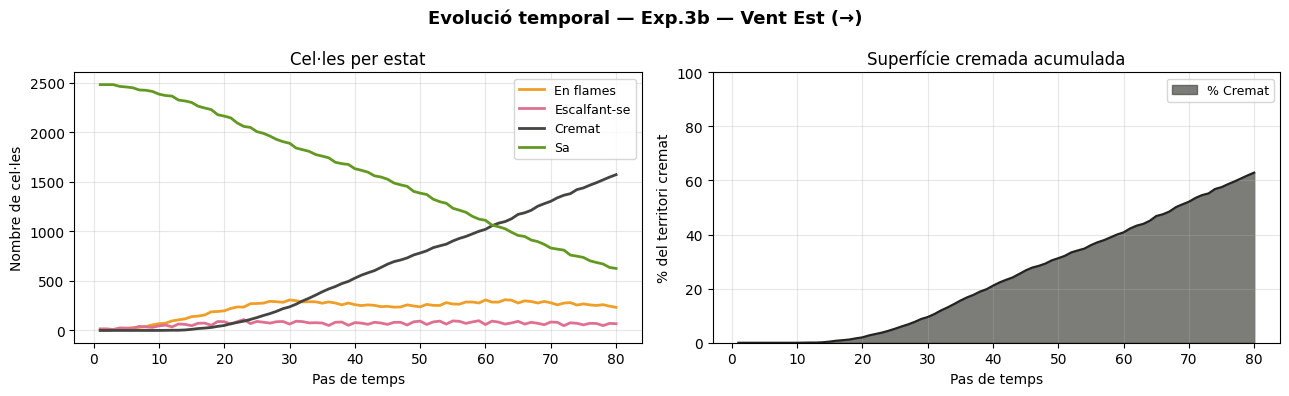

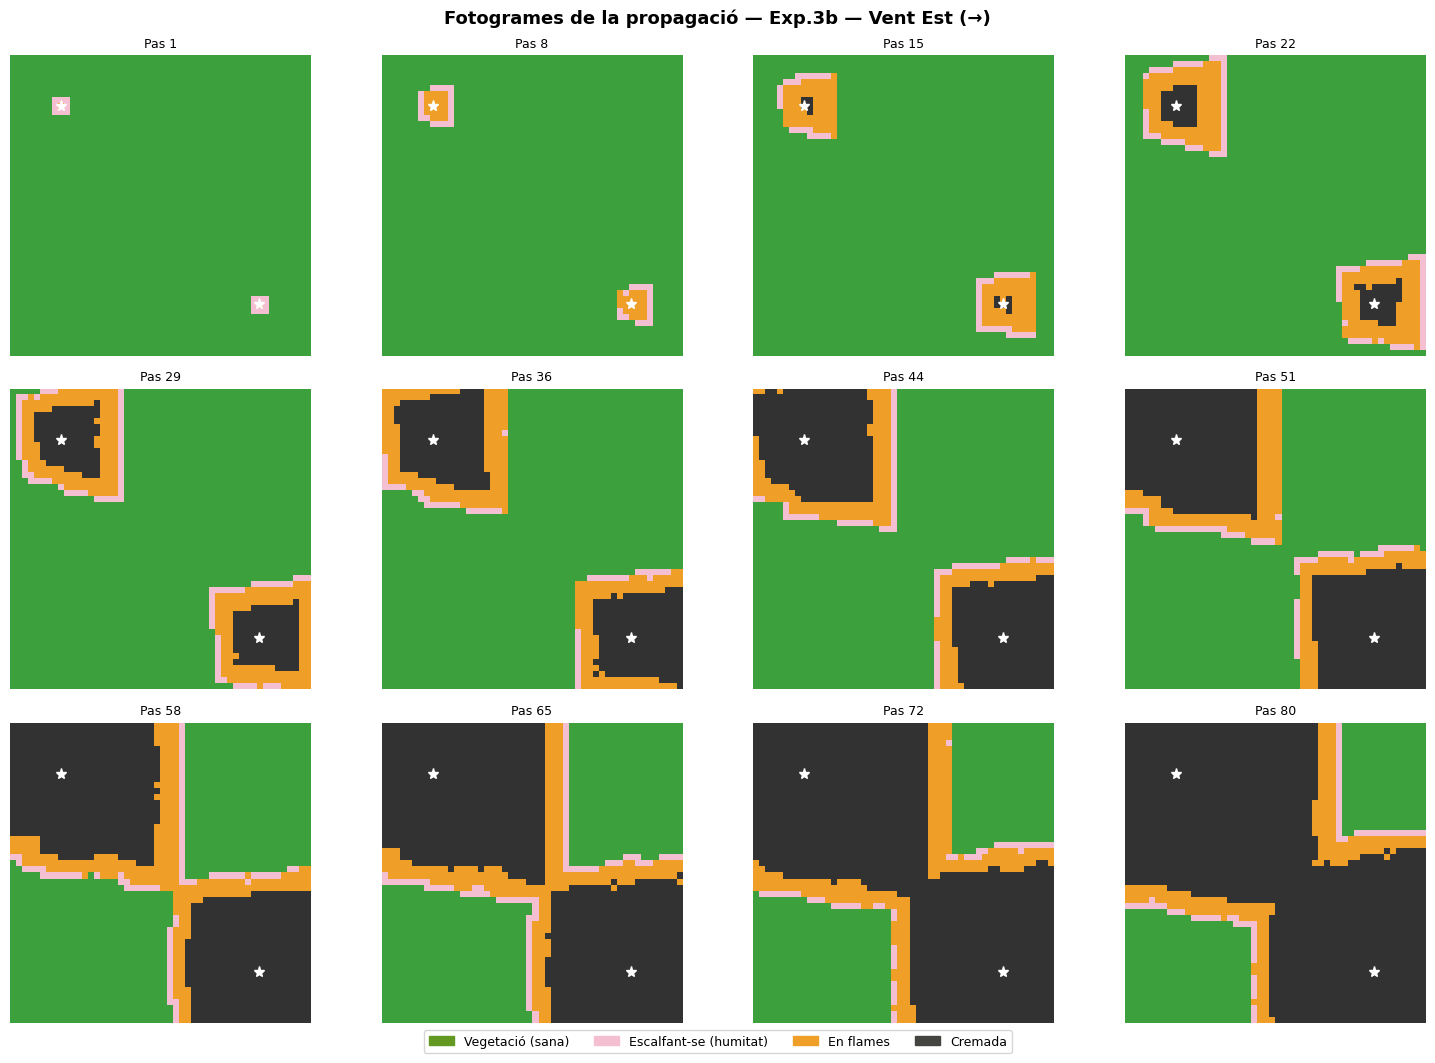


EXPERIMENT: Exp.3c — Vent Sud (↓)
  Focus d'ignició : [(8, 8), (41, 41)]
  Vent            : (1, 0) (sud)
   Focus [  8,  8]  veg=11h  hum=3.0h
   Focus [ 41, 41]  veg=10h  hum=3.1h

  Resultat final — Pas 80:
    Cremat :  1550 cel·les (62.0%)
    Sa     :   640 cel·les (25.6%)


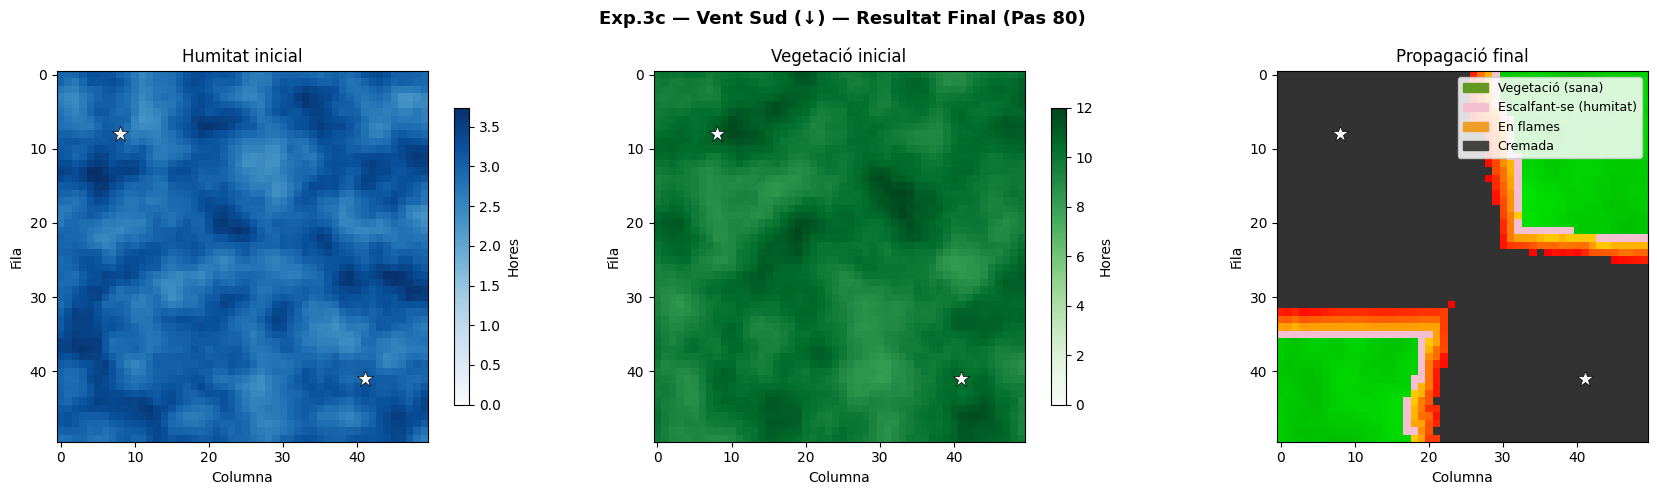

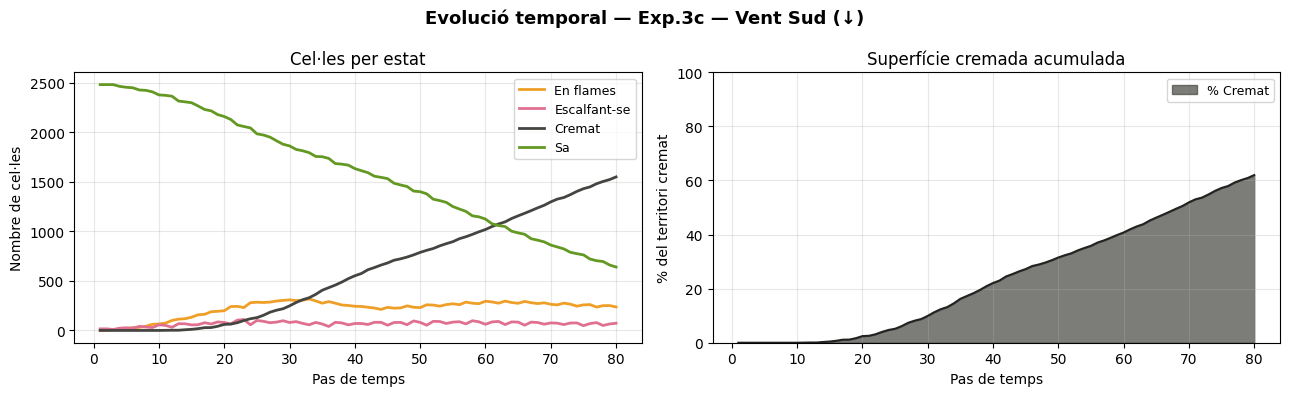

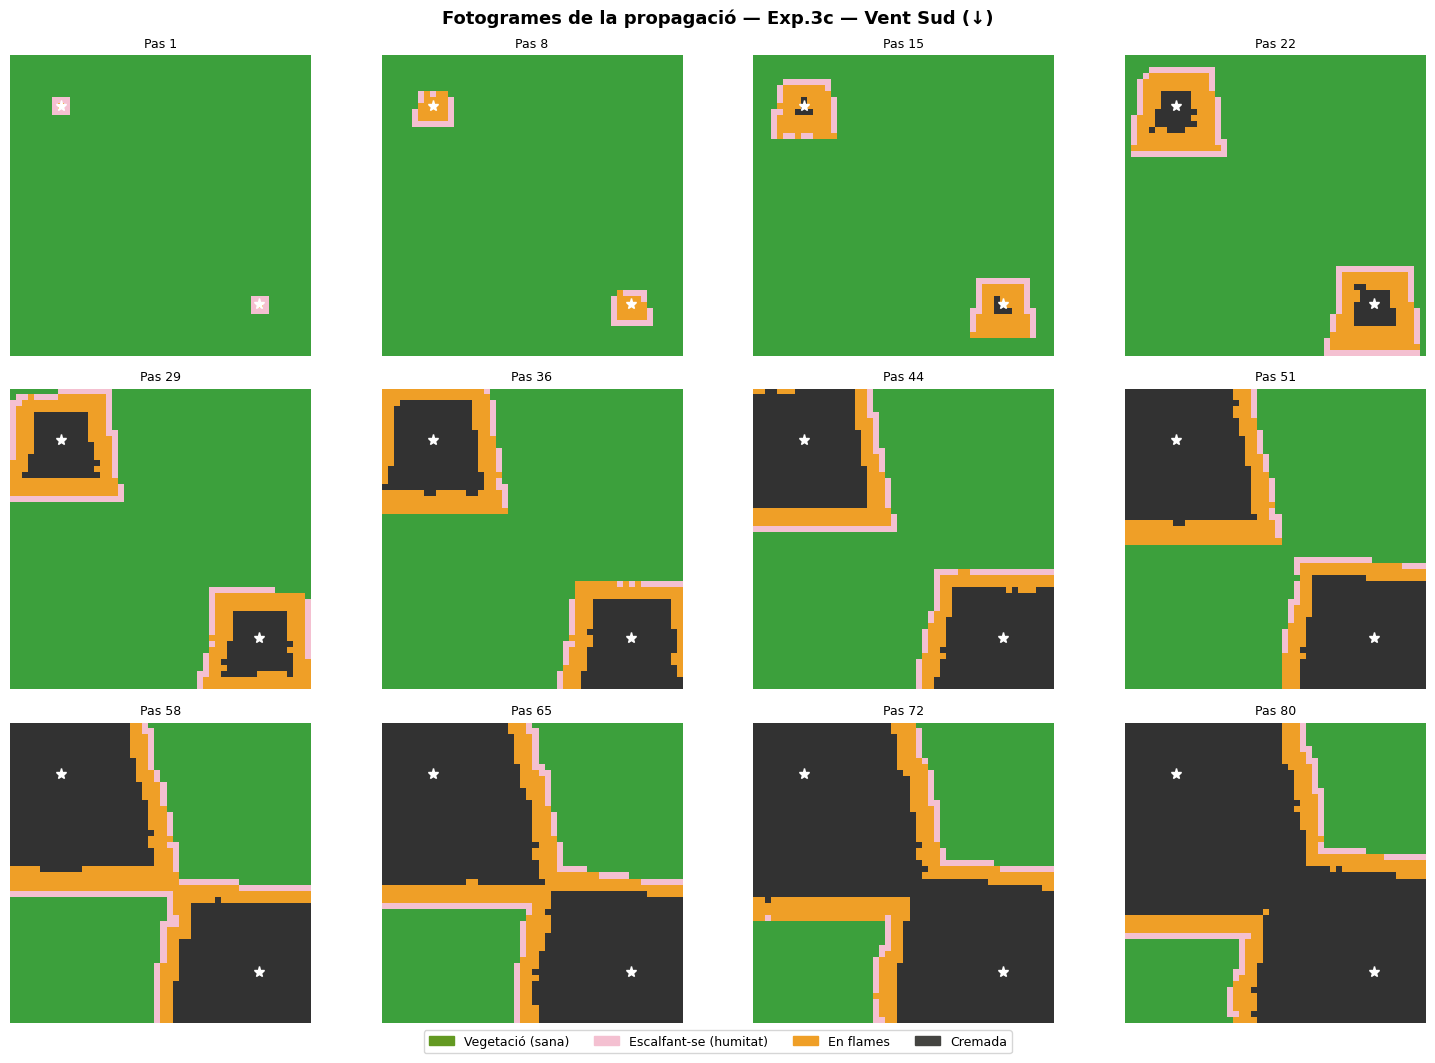


EXPERIMENT: Exp.3d — Vent SE (↘)
  Focus d'ignició : [(8, 8), (41, 41)]
  Vent            : (1, 1) (sud-est)
   Focus [  8,  8]  veg=11h  hum=3.0h
   Focus [ 41, 41]  veg=10h  hum=3.1h

  Resultat final — Pas 80:
    Cremat :  1476 cel·les (59.0%)
    Sa     :   718 cel·les (28.7%)


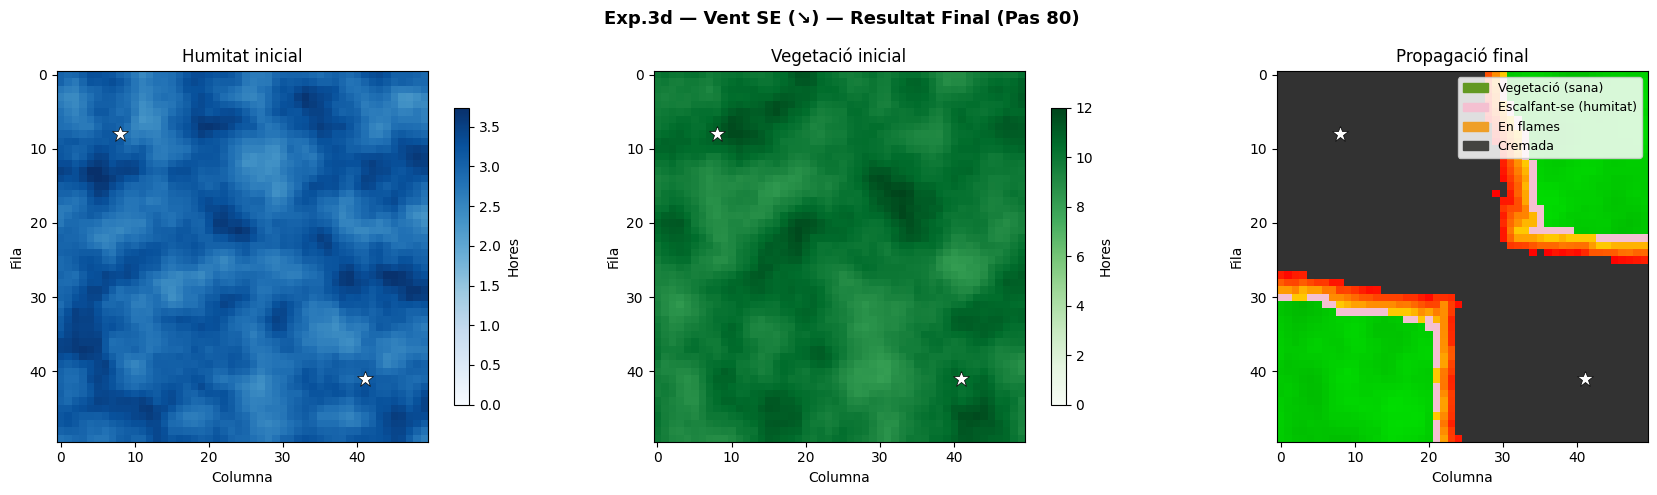

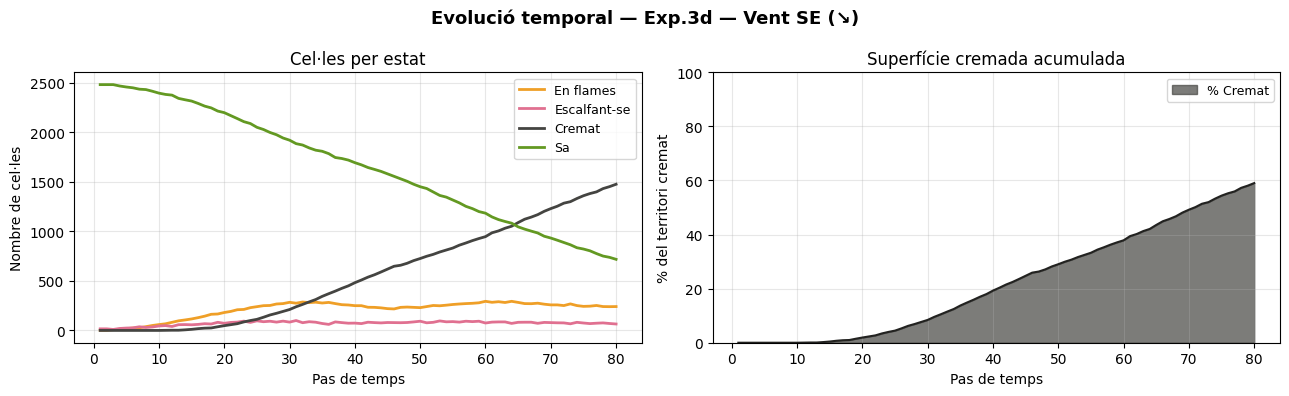

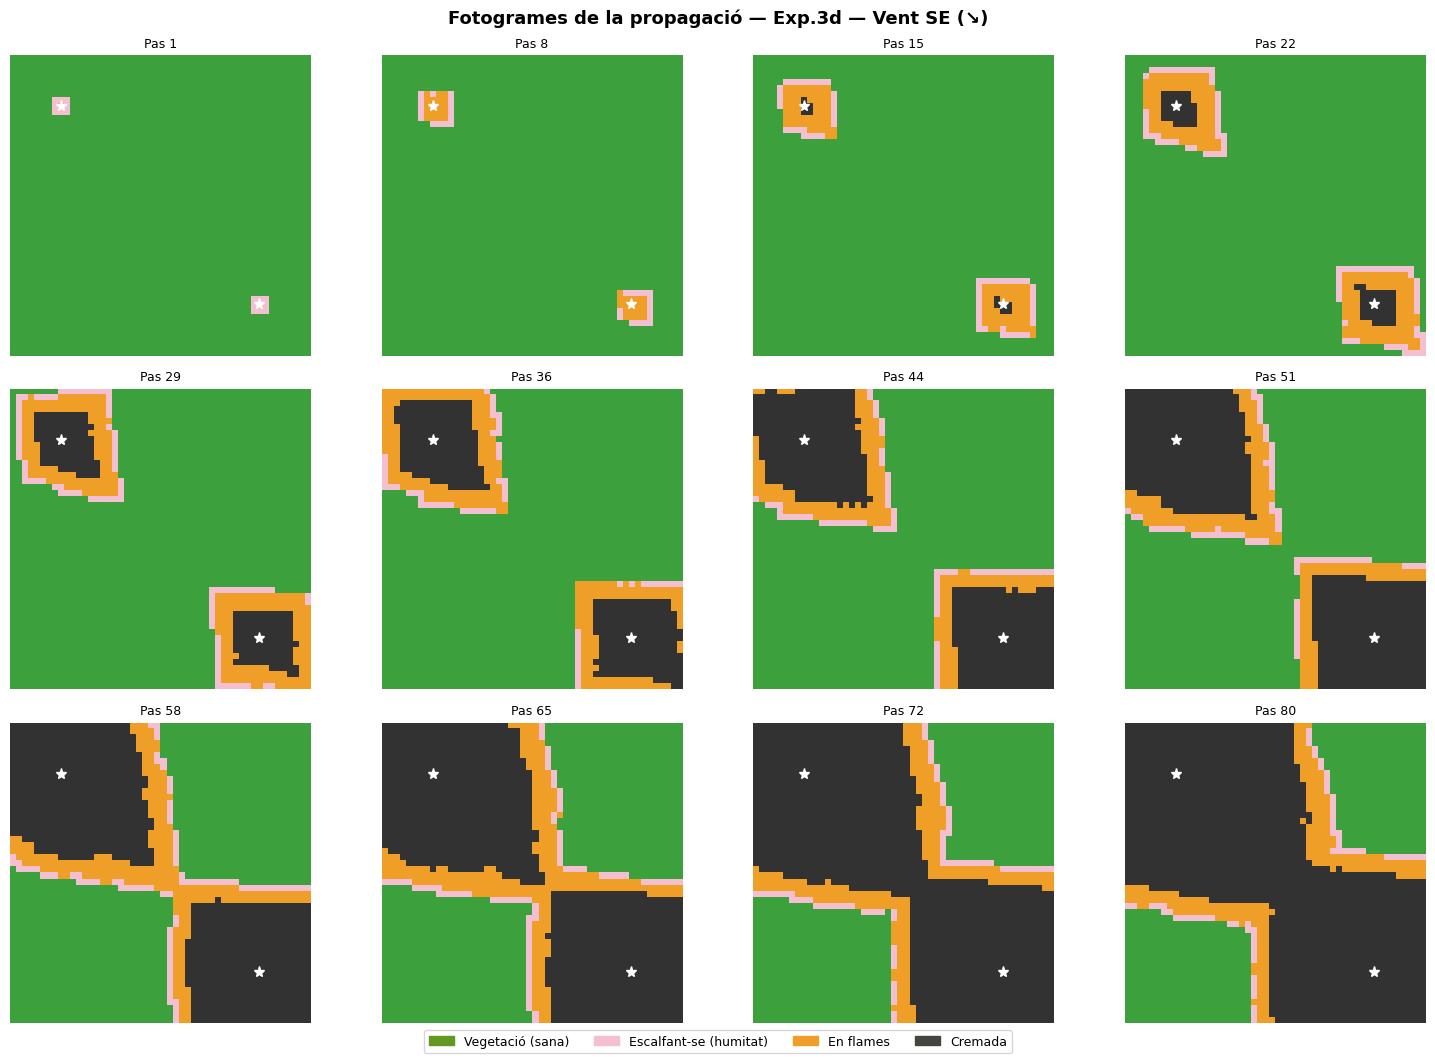

In [17]:
# Condicions de vent a comparar
wind_conditions = [
    {"label": "Exp.3a — Sense vent",    "wind": (0, 0)},
    {"label": "Exp.3b — Vent Est (→)",  "wind": (0, 1)},
    {"label": "Exp.3c — Vent Sud (↓)",  "wind": (1, 0)},
    {"label": "Exp.3d — Vent SE (↘)",   "wind": (1, 1)},
]

# Dos focus d'ignició per a tots els sub-experiments
ignite_exp3 = [(8, 8), (41, 41)]

results_exp3 = []
for cond in wind_conditions:
    ca_e, sh_e = run_experiment(
        label=cond["label"],
        hum_grid=hum_grid,
        veg_grid=veg_grid,
        ignite_cells=ignite_exp3,
        wind_dir=cond["wind"],
        max_steps=MAX_STEPS,
    )
    results_exp3.append((cond["label"], ca_e, sh_e))

## Resum comparatiu dels experiments

Taula resum del resultat final de cada experiment: passos fins l'extinció i % de territori cremat.

In [18]:
# Recollim tots els experiments en una llista
all_experiments = [
    ("Simulació principal (base, 1 focus)", ca, stats_history),
    ("Exp.1 (base, 3 focus)",               ca_exp1, sh1),
    ("Exp.2a (alta humitat, 1 focus)",       ca_exp2a, sh2a),
    ("Exp.2b (alta humitat, 4 focus)",       ca_exp2b, sh2b),
] + [(lbl, ca_e, sh_e) for (lbl, ca_e, sh_e) in results_exp3]

print(f"{'Experiment':<48}  {'Passos':>7}  {'% Cremat':>9}  {'% Sa':>7}")
print("-" * 76)
for (label, ca_e, sh_e) in all_experiments:
    sf = ca_e.stats()
    pct_b = sf['burned'] / sf['total'] * 100
    pct_s = sf['safe']   / sf['total'] * 100
    print(f"{label:<48}  {sf['step']:>7}  {pct_b:>8.1f}%  {pct_s:>6.1f}%")

Experiment                                         Passos   % Cremat     % Sa
----------------------------------------------------------------------------
Simulació principal (base, 1 focus)                    80      45.3%    36.0%
Exp.1 (base, 3 focus)                                  80      68.8%    17.8%
Exp.2a (alta humitat, 1 focus)                         80      13.7%    76.4%
Exp.2b (alta humitat, 4 focus)                         80      35.2%    51.0%
Exp.3a — Sense vent                                    80      50.6%    36.3%
Exp.3b — Vent Est (→)                                  80      62.9%    25.0%
Exp.3c — Vent Sud (↓)                                  80      62.0%    25.6%
Exp.3d — Vent SE (↘)                                   80      59.0%    28.7%


---
## Conclusions

### Model implementat
S'ha implementat un **automata cellular m:n-CA^k** per simular la propagacio d'un incendi forestal sobre una graella bidimensional de **{ROWS}x{COLS} cel·les** llegida de fitxers generats sinteticament en format IDRISI32. El model utilitza **tres capes**:

1. **Capa d'humitat** (de `humidity.doc/img`): retarda l'inici del foc. Les cel·les amb humitat 0 s'encenen directament; les altres passen per l'estat `MOIST` fins esgotar la humitat.
2. **Capa de vegetacio** (de `vegetation.doc/img`): determina durant quants passos crema cada cel·la.
3. **Capa de propagacio** (dinamica): `EMPTY -> MOIST -> BURNING -> BURNED`.

S'ha definit la humitat en el rang [1, 5] i la vegetacio en el rang [5, 15], ja que l'enunciat no fixa valors concrets i aquests rangs mantenen una dinamica visible i equilibrada entre retard i combustio.

### Aspectes clau de la implementacio
- **Temporitzadors incrementals**: `burn_timer` i `hum_timer` s'incrementen pas a pas, pero el canvi d'estat es produeix **unicament quan el comptador assoleix el llindar**. Evita recalcular la condicio a cada iteracio.
- **Multiples focus d'ignicio**: suport per a qualsevol nombre de cel·les inicials de foc, simulant incendis originals multiples o propagacio per espurnes.
- **Grafiques incloses a tots els experiments**: cada simulacio genera el grid de propagacio i les grafiques de tendencia (cel·les per estat + % cremat acumulat).

### Observacions dels experiments
- **Exp.1** (multiples focus): els fronts independents fusionen rapidament, cremant una fraccio major del territori en menys passos que amb un sol focus.
- **Exp.2** (alta humitat): el retard es notori. Quatre focus als cantons cremen significativament mes superficie que un de central, perque aprofiten les vores sense veins que ja estan escalfant-se.
- **Exp.3** (vent): el vent dirigeix asimetricament el front; la seva influencia es modesta en el model determinista (afecta l'ordre de processament de veins), pero el percentatge cremat final varia depenent de si el front arriba a zones d'alta o baixa vegetacio.

### Limitacions i possibles millores
- La topografia (pendent) no es considera, malgrat ser molt rellevant en incendis reals.
- El vent es constant en el temps i l'espai; un camp vectorial variable seria mes realista.
- Afegir un component estocastic (probabilitat de propagacio) donaria variabilitat als resultats.

---
## Us de la Intel·ligencia Artificial

Per al desenvolupament d'aquesta practica s'ha fet servir **Claude (Anthropic)** com a eina de suport.

L'us de la IA ha estat util principalment en tres ambits:

1. **Estructuracio del codi**: ajuda a organitzar el notebook en dos apartats (generacio de fitxers + simulacio), i a definir la funcio `run_experiment` per evitar duplicar codi entre experiments.
2. **Correccio de la logica dels temporitzadors**: la IA va identificar que en versions anteriors els estats es podien actualitzar a cada pas en lloc d'esperar al llindar, i va proporcionar la implementacio correcta amb comptadors incrementals.
3. **Multiples focus i grafiques**: la IA va suggerir la creacio de la funcio generica `run_experiment` que automatitza la generacio de totes les grafiques per a cada experiment.

En general, la IA ha accelerat el proces i ha permes centrar l'esforc en les decisions de disseny del model. Les decisions clau (determinisme del CA, tractament de la humitat i vegetacio, estructura de dos apartats) s'han pres de forma independent, usant la IA com a eina de verificacio, implementacio i millora del codi existent.